Task : Price Prediction for Airbnb Listings
Goal:
Predict the price of an Airbnb listing based on the features provided in the
dataset .

Dataset Info:

• id: Unique identifier for each listing

• name: Name of the Airbnb listing

• rating: Average rating of the listing

• reviews: Number of reviews received

• host_name: Name of the host

• host_id: Unique identifier for the host


• address: Location of the listing (city, region, country)


• features: Summary of features (number of guests, bedrooms, beds,

bathrooms)

• amenities: List of amenities provided

• price: Price per night in the local currency

• country: Country where the listing is located

• bathrooms: Number of bathrooms

• beds: Number of beds

• guests: Number of guests the listing can accommodate


• toilets: Number of toilets

• bedrooms: Number of bedrooms

• studios: Number of studio units

• checkin: Check-in time

• checkout: Check-out time

In [171]:
#importing necessary libraries:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 1: Exploratory Data Analysis (EDA)

Understanding the dataset

In [172]:
df = pd.read_csv("airbnb.csv")
# print(df.head)
print(f"dataset shape : {df.shape}")
print("\n")
print(f"columns: {df.columns.tolist()}")
print("\n")
print(f"Dataset information: {df.info()}")
print("\n")
print(f"columns: {df.describe()}")

dataset shape : (12805, 23)


columns: ['Unnamed: 0', 'id', 'name', 'rating', 'reviews', 'host_name', 'host_id', 'address', 'features', 'amenities', 'safety_rules', 'house_rules', 'img_links', 'price', 'country', 'bathrooms', 'beds', 'guests', 'toilets', 'bedrooms', 'studios', 'checkin', 'checkout']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    12805 non-null  int64  
 1   id            12805 non-null  int64  
 2   name          12805 non-null  object 
 3   rating        12805 non-null  object 
 4   reviews       12805 non-null  object 
 5   host_name     12797 non-null  object 
 6   host_id       12805 non-null  float64
 7   address       12805 non-null  object 
 8   features      12805 non-null  object 
 9   amenities     12805 non-null  object 
 10  safety_rules  12805 non-null  object 
 11  house_rules   12805 non-

In [173]:
print(f"data types : {df.dtypes}")

data types : Unnamed: 0        int64
id                int64
name             object
rating           object
reviews          object
host_name        object
host_id         float64
address          object
features         object
amenities        object
safety_rules     object
house_rules      object
img_links        object
price             int64
country          object
bathrooms         int64
beds              int64
guests            int64
toilets           int64
bedrooms          int64
studios           int64
checkin          object
checkout         object
dtype: object


In [174]:
print(f"missing values per column: {df.isnull().sum()}")

missing values per column: Unnamed: 0         0
id                 0
name               0
rating             0
reviews            0
host_name          8
host_id            0
address            0
features           0
amenities          0
safety_rules       0
house_rules        0
img_links          0
price              0
country            0
bathrooms          0
beds               0
guests             0
toilets            0
bedrooms           0
studios            0
checkin          800
checkout        2450
dtype: int64


In [175]:
print(f"missing value percentage: {df.isnull().mean()*100}")

missing value percentage: Unnamed: 0       0.000000
id               0.000000
name             0.000000
rating           0.000000
reviews          0.000000
host_name        0.062476
host_id          0.000000
address          0.000000
features         0.000000
amenities        0.000000
safety_rules     0.000000
house_rules      0.000000
img_links        0.000000
price            0.000000
country          0.000000
bathrooms        0.000000
beds             0.000000
guests           0.000000
toilets          0.000000
bedrooms         0.000000
studios          0.000000
checkin          6.247560
checkout        19.133151
dtype: float64


In [176]:
print("showing first 10 rows of our dataset: ")
print(df.head(10))

showing first 10 rows of our dataset: 
   Unnamed: 0        id                                               name  \
0           0  49849504                                     Perla bungalov   
1           1  50891766  Authentic Beach Architect Sheltered Villa with...   
2           2  50699164                                  cottages sataplia   
3           3  49871422                        Sapanca Breathable Bungalow   
4           4  51245886                                      Bungalov Ev 2   
5           5  48650769                      CasaMia White Suite Treehouse   
6           6  50765985                                     Ladin Bungalow   
7           7  40947216                                     Lavender House   
8           8  34043569                                           Prince's   
9           9  42075682                    The Cottage, Private Pool Villa   

  rating reviews    host_name      host_id  \
0   4.71      64    Mehmetcan  357334205.0   
1    New  

Checking data distribution

In [177]:
numeric_columns = ['bathrooms', 'beds',
                   'bedrooms', 'guests', 'studios', 'toilets']
print("Summary satatics of numeric columns: ")
print(df[numeric_columns].isnull().sum())

print(df[numeric_columns])

Summary satatics of numeric columns: 
bathrooms    0
beds         0
bedrooms     0
guests       0
studios      0
toilets      0
dtype: int64
       bathrooms  beds  bedrooms  guests  studios  toilets
0              1     1         2       2        0        0
1              2     2         2       4        0        0
2              1     3         1       4        0        0
3              1     2         1       4        0        0
4              1     1         1       2        0        0
...          ...   ...       ...     ...      ...      ...
12800          8     0         0       4        0        0
12801          0     1         1       2        0        1
12802          1     2         1       2        0        0
12803          2     4         2       8        0        0
12804          1     2         1       5        0        0

[12805 rows x 6 columns]


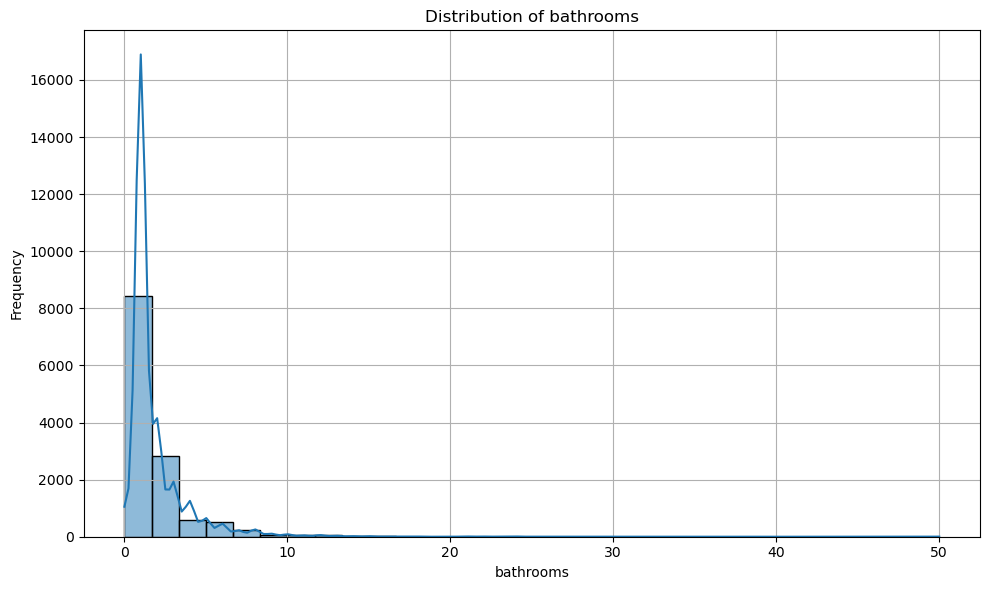

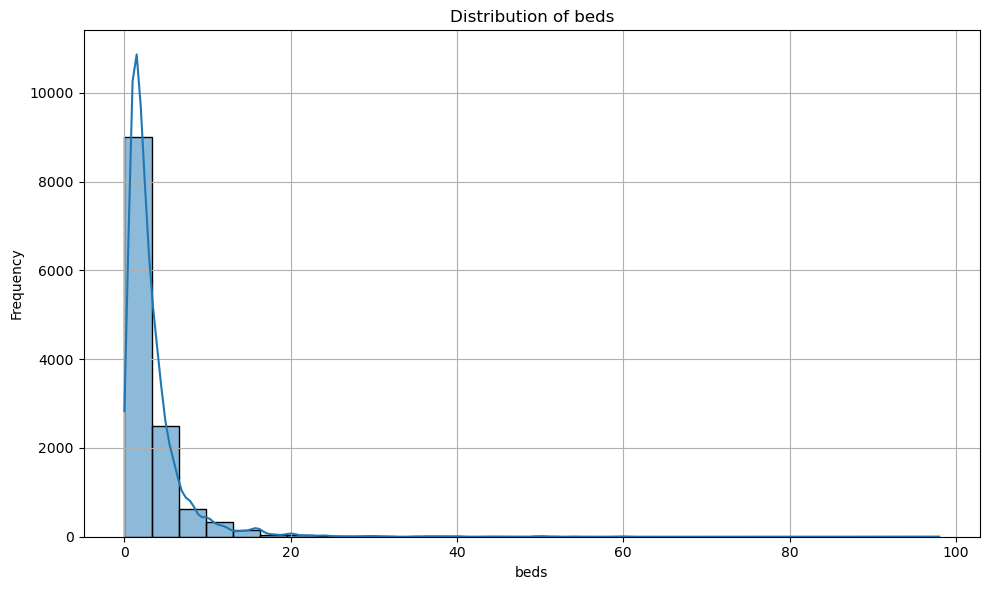

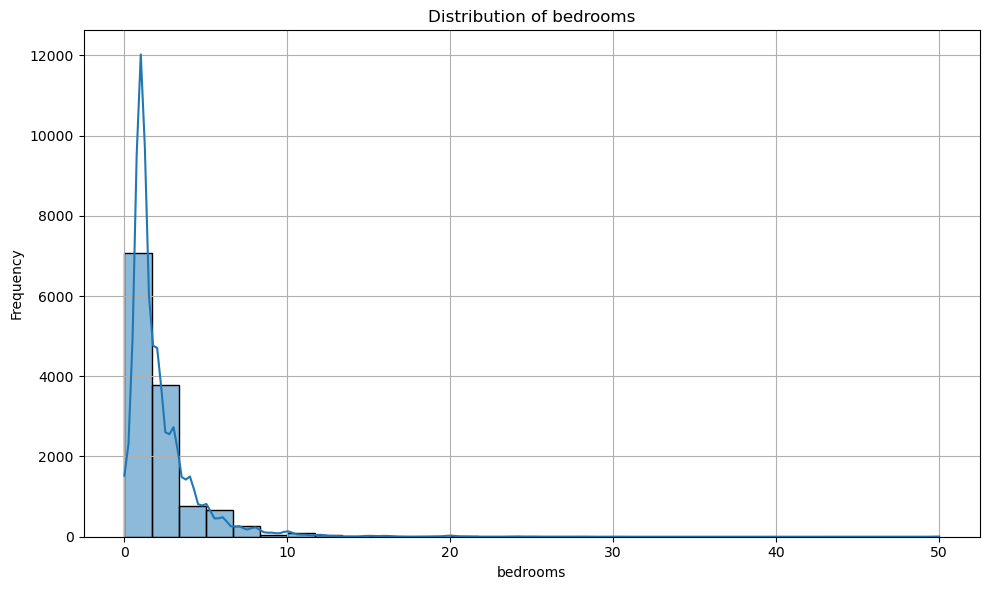

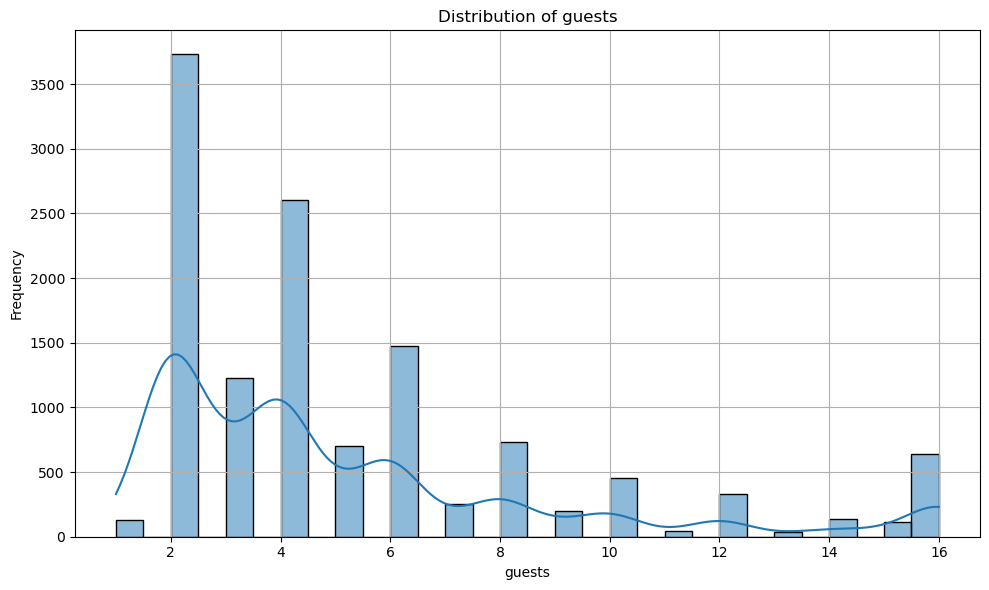

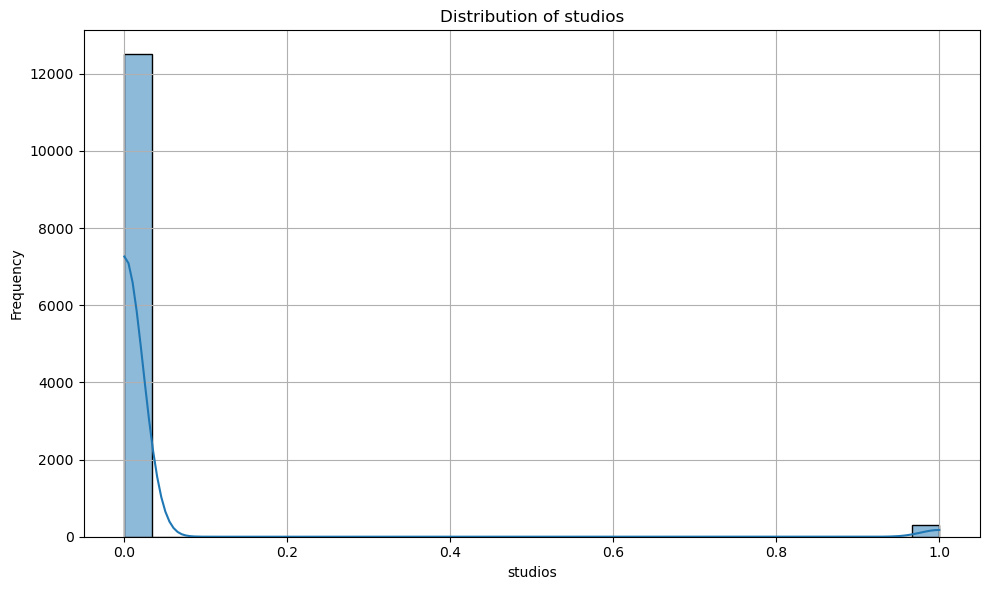

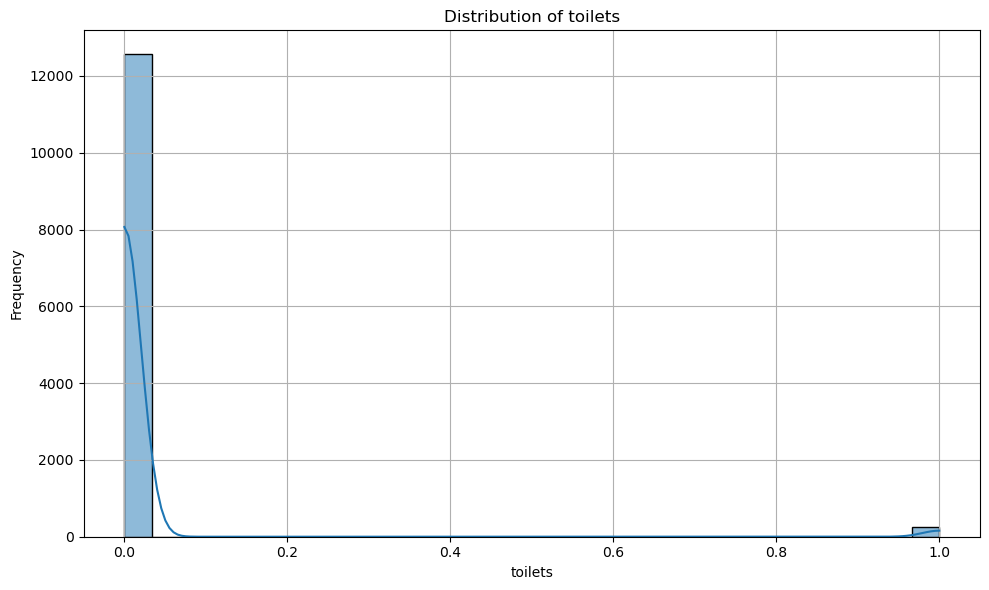

In [178]:
numeric_columns = ['bathrooms', 'beds',
                   'bedrooms', 'guests', 'studios', 'toilets']

for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

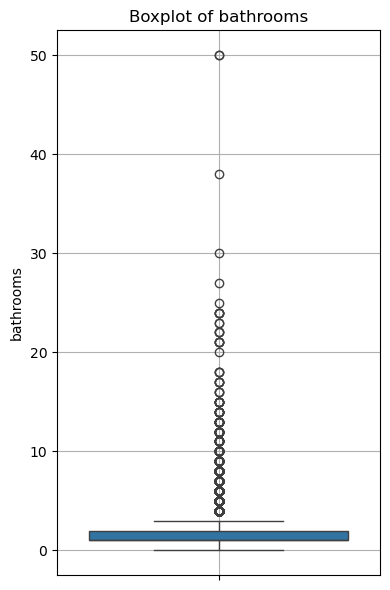

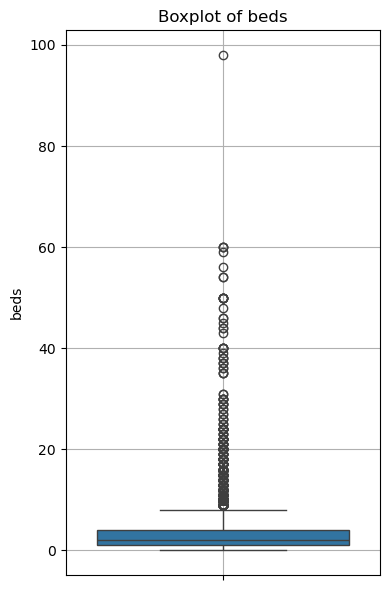

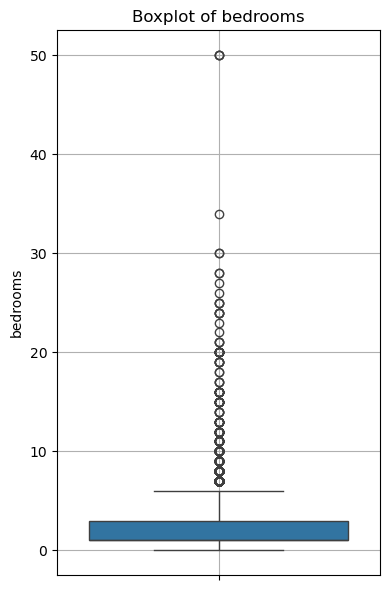

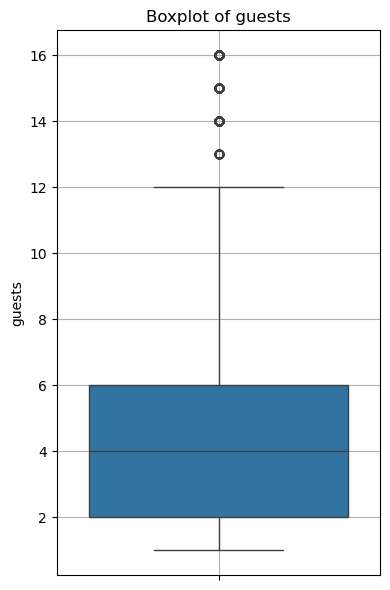

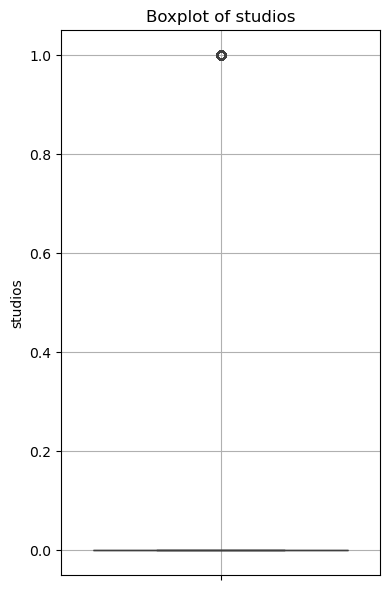

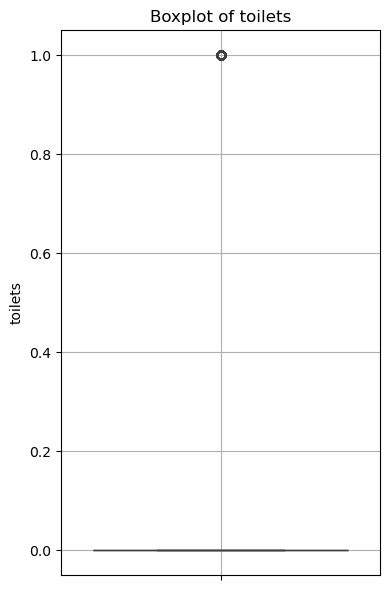

In [179]:
numeric_columns = ['bathrooms', 'beds',
                   'bedrooms', 'guests', 'studios', 'toilets']

for col in numeric_columns:
    plt.figure(figsize=(4, 6)) #(width,height)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

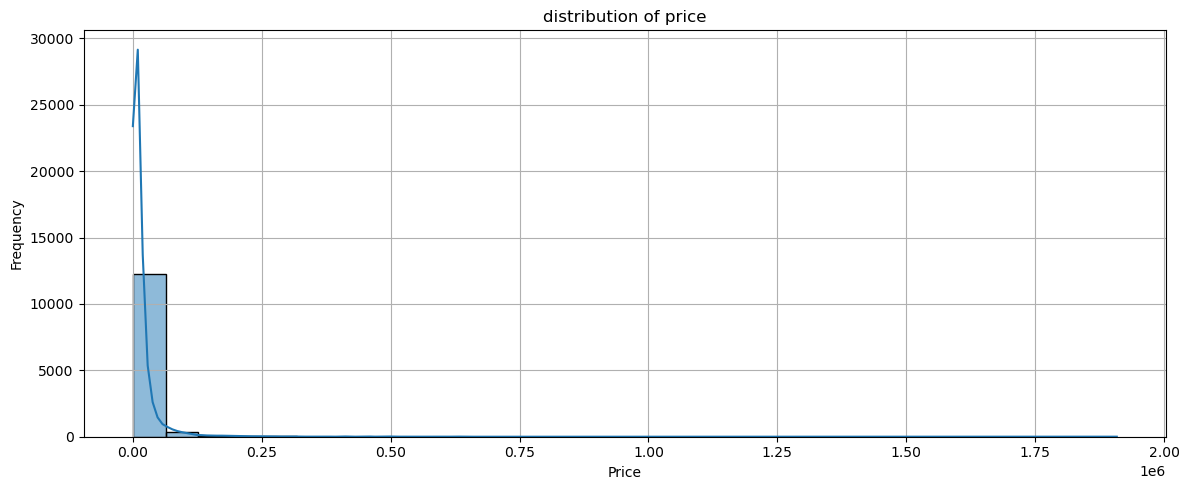

In [180]:
# histogram for price
plt.figure(figsize=(12,5))
sns.histplot(df['price'].dropna(),kde=True,bins=30)
plt.title("distribution of price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

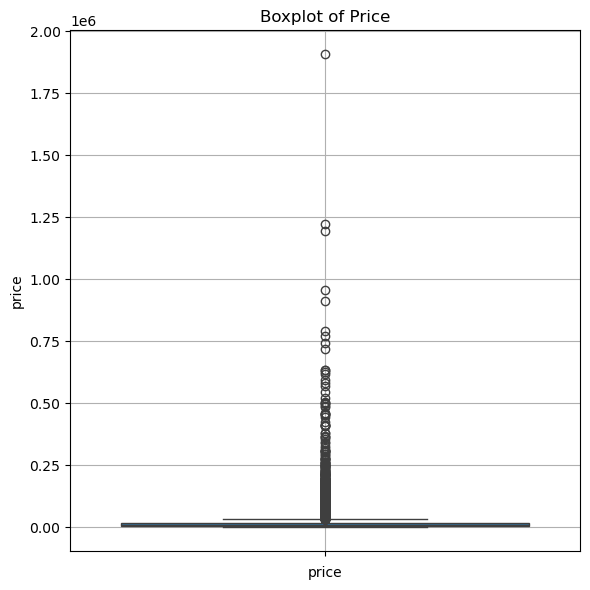

In [181]:
# Boxplot for price
plt.figure(figsize=(6,6))
sns.boxplot(y=df['price'].dropna())
plt.title("Boxplot of Price")
plt.xlabel("price")
plt.grid(True)
plt.tight_layout()
plt.show()

Correlation Analysis:

In [182]:
correlation_matrix = df[numeric_columns].corr()
print(f"correlation matrix value: {correlation_matrix}")

correlation matrix value:            bathrooms      beds  bedrooms    guests   studios   toilets
bathrooms   1.000000  0.603499  0.820780  0.665468 -0.065229 -0.125441
beds        0.603499  1.000000  0.772294  0.673115 -0.058969 -0.041979
bedrooms    0.820780  0.772294  1.000000  0.713547 -0.140732 -0.069573
guests      0.665468  0.673115  0.713547  1.000000 -0.077903 -0.069845
studios    -0.065229 -0.058969 -0.140732 -0.077903  1.000000  0.004492
toilets    -0.125441 -0.041979 -0.069573 -0.069845  0.004492  1.000000


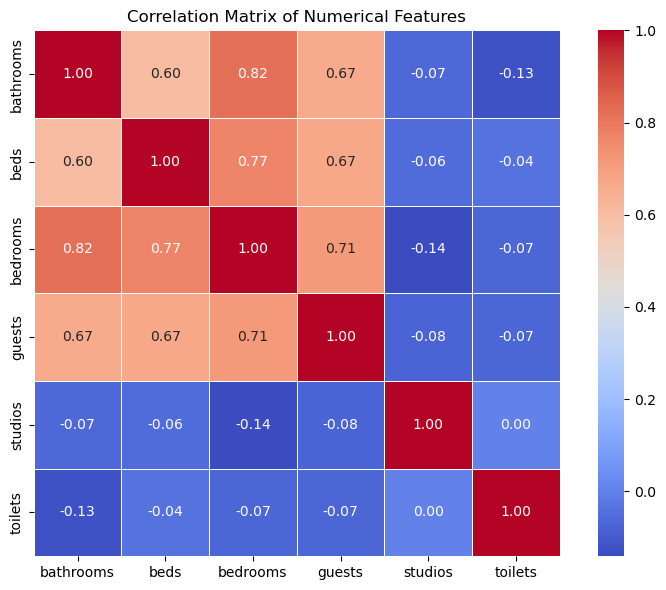

In [183]:
# displaying correlation matrix:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm',square=True,linewidth=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# Explanation of correlations:
* strong positive correlation indicates that one variable increases, the other tends to increase too. 
    1. bathrooms & bedrooms (0.82) more bedrooms comes with more bathrooms
    2. bedrooms and beds (0.77) more bedrooms means more beds.
    3. guests & bedrooms (0.71) more guests == more bedrooms needed.
    4. bathrooms & guests (0.67) more guest need more bathrooms.
    5. beds & guests (0.67) more guests so more bed needed.

* Moderate or weak correlation:
    1. bathrooms & beds (0.60) means more beds accompany more bathrooms

* Negative correlation means, if one variable increases another tends to decrease.
    1. studios & bedrooms (-0.14) which shows studios tends to have no separate bedrooms.
    2. bathrooms & studios (-0.065) studios often have fwer bathrooms.
    3. toiles(mislabeled in the dataset, must be toilets) & bathrooms (-0.07) generally weak correlations cause some times bathrooms have toilets inside so separate toilets are not that much necessary.

* No Correlation (tends to 0):
    1. studios & toilets (0.0045) they don't seem related at all.


# Analyzing Categorical Features:

<Axes: title={'center': 'listing count by country'}, ylabel='country'>

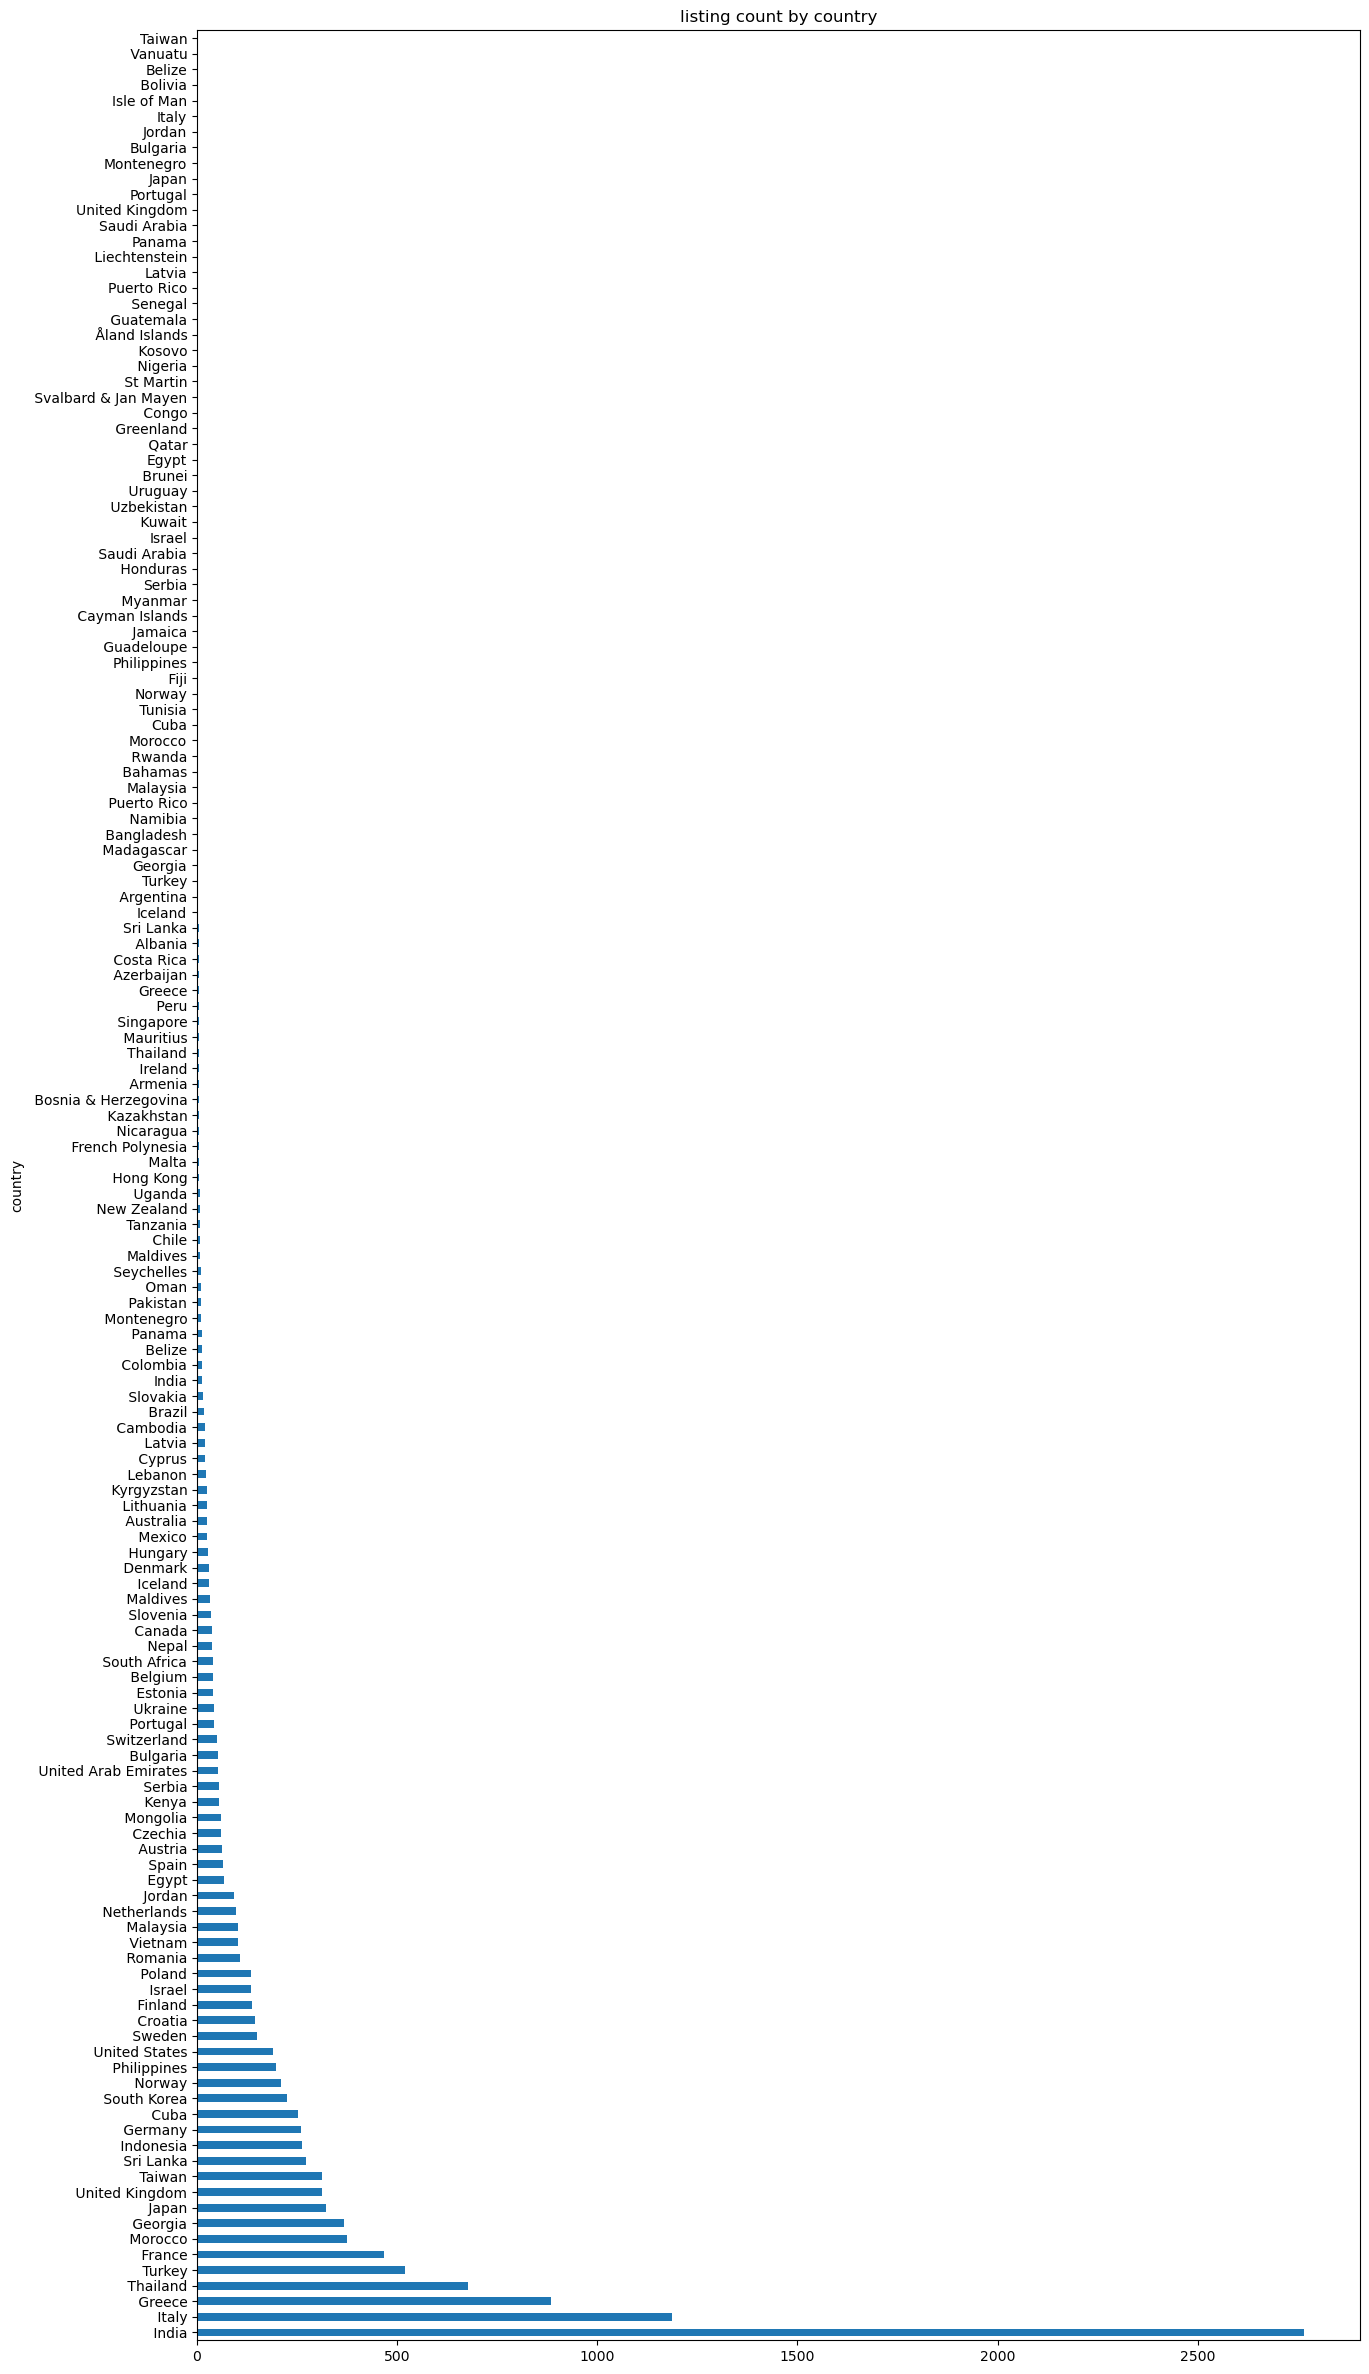

In [184]:
# Country distribution
df['country'].value_counts().plot(kind='barh',figsize=(15,30),title="listing count by country")

* here we can see India has the highest listing and several countrys have the lowest or zero listing  

<Axes: title={'center': 'Top 10 checkin times'}, xlabel='checkin'>

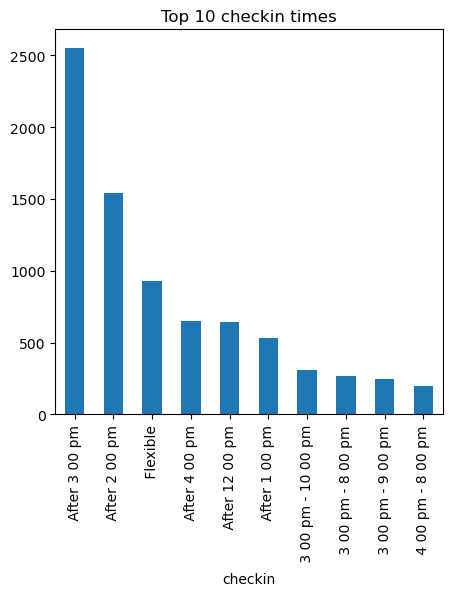

In [185]:
# check-in and check-out distribution
df['checkin'].value_counts().head(10).plot(kind='bar', figsize=(5,5),title="Top 10 checkin times")

* we can see the highest number of checkins happens during afternoon (after 3pm)

<Axes: title={'center': 'Top 10 checkout times'}, xlabel='checkout'>

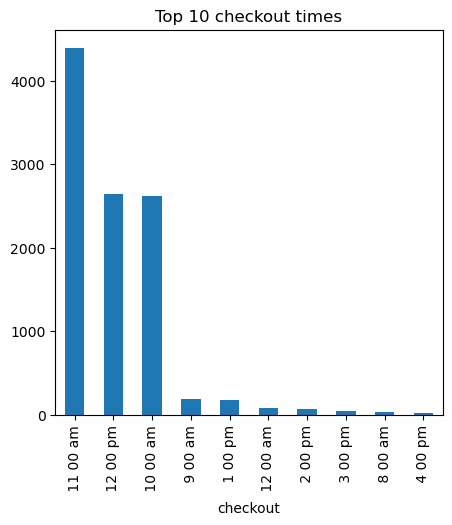

In [186]:
df['checkout'].value_counts().head(10).plot(kind='bar', figsize=(5, 5), title="Top 10 checkout times")

* from the above bar-chart we can see the most checkouts take place during 11 am in the morning.

In [187]:
# ratings distribution
df['rating_cleaned'] = pd.to_numeric(df['rating'],errors='coerce')
df[['rating', 'rating_cleaned']].head(10)

,rating,rating_cleaned
0,4.71,4.71
1,New,NaN
2,4.85,4.85
3,5.0,5.00
4,New,NaN
5,New,NaN
6,New,NaN
7,New,NaN
8,New,NaN
9,4.67,4.67


<Axes: title={'center': 'rating distribution'}, xlabel='rating_cleaned'>

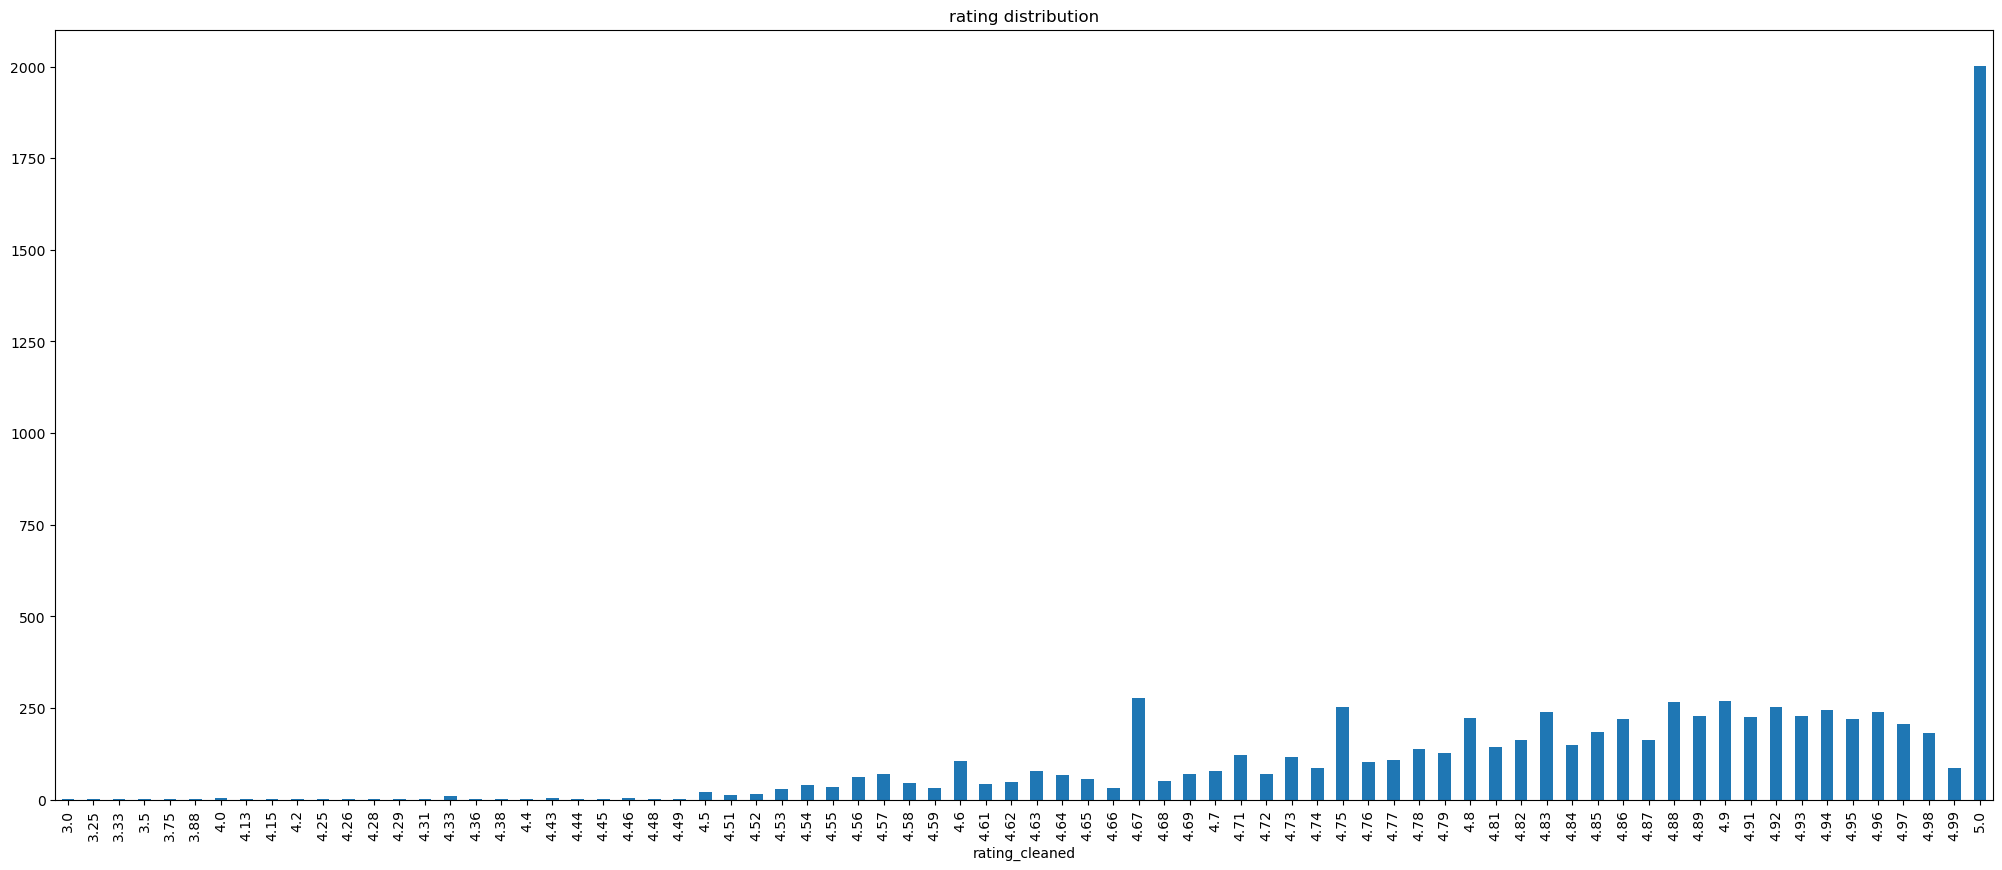

In [188]:
df['rating_cleaned'].value_counts().sort_index().plot(kind='bar',figsize=(25,10),title="rating distribution")

* here we can see most common rating band is lies between 4.5 to 5.0 

<Axes: title={'center': 'safety rule frequency'}, ylabel='safety_rules'>

/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 989187 (\U000f1803) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 1019905 (\U000f9001) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 989190 (\U000f1806) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 989185 (\U000f1801) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989187 (\U000f1803) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWa

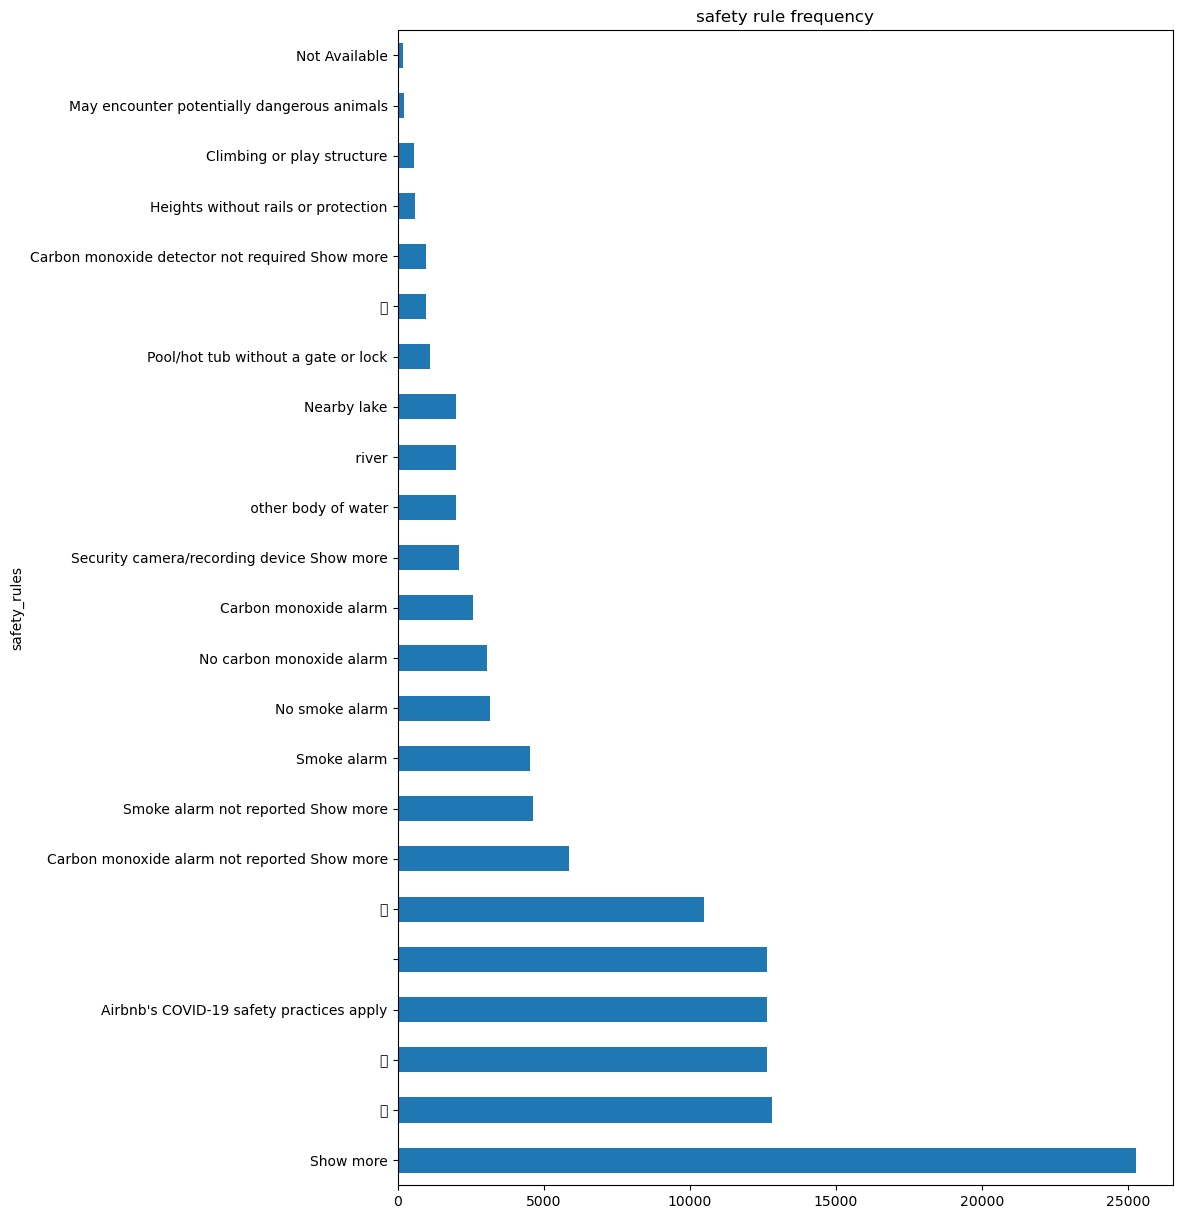

In [189]:
# safety rules / house rules distribution
df['safety_rules'].str.split(',').explode().value_counts().plot(kind='barh',title="safety rule frequency",figsize=(10,15))

* here if we exclude show more and gibberish data covid-19 safety practices apply is the highest common safety rule.

<Axes: title={'center': 'house rule frequency'}, ylabel='house_rules'>

/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 989447 (\U000f1907) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989447 (\U000f1907) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


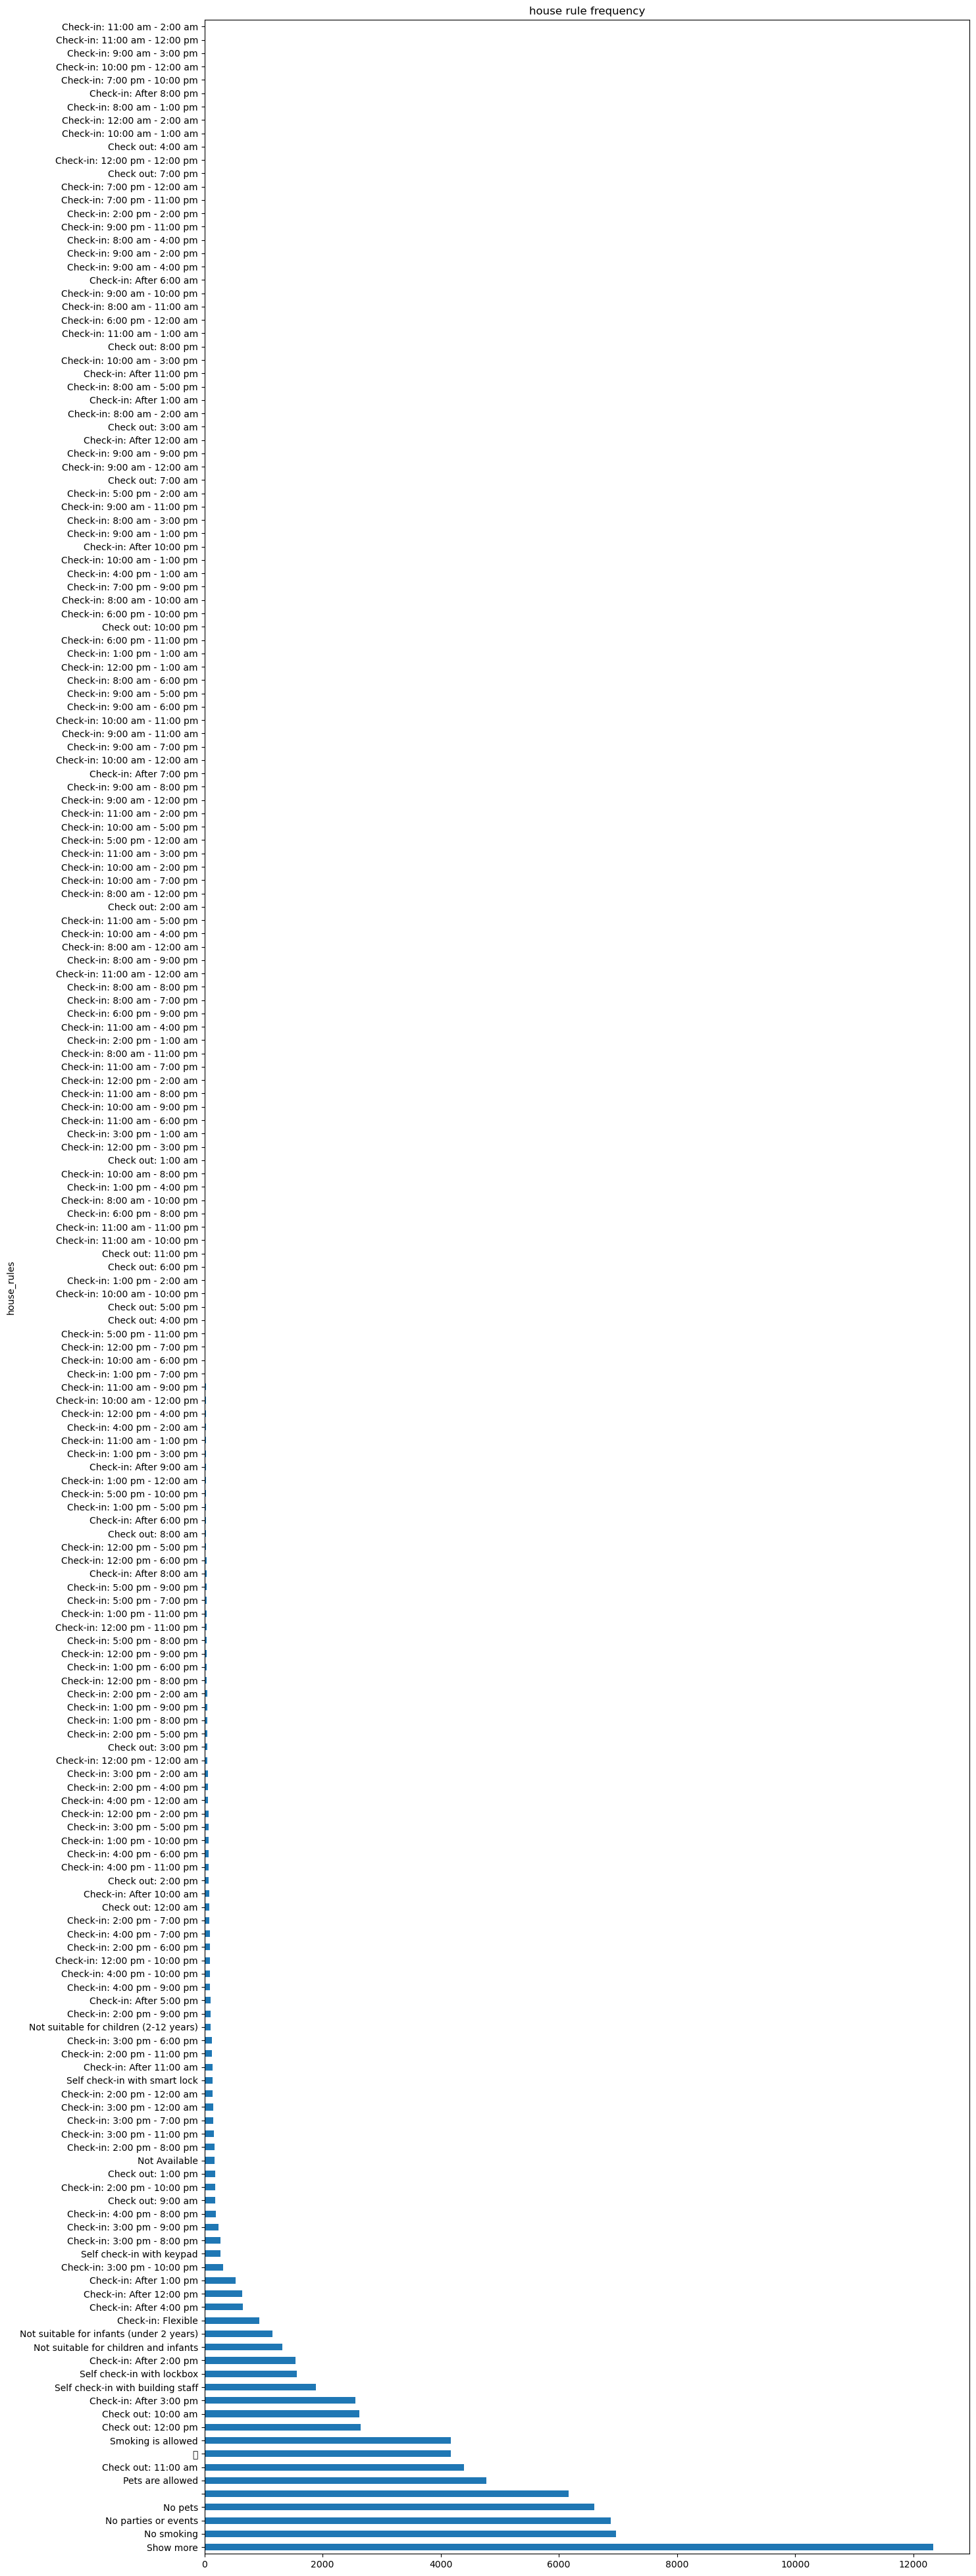

In [190]:
df['house_rules'].str.split(',').explode().value_counts().plot(
    kind='barh', title="house rule frequency",figsize=(15,50))

* if we exclude show more part, no smoking in the house is the top most house rule.

<Axes: title={'center': 'Top 20 amenities'}, ylabel='amenities'>

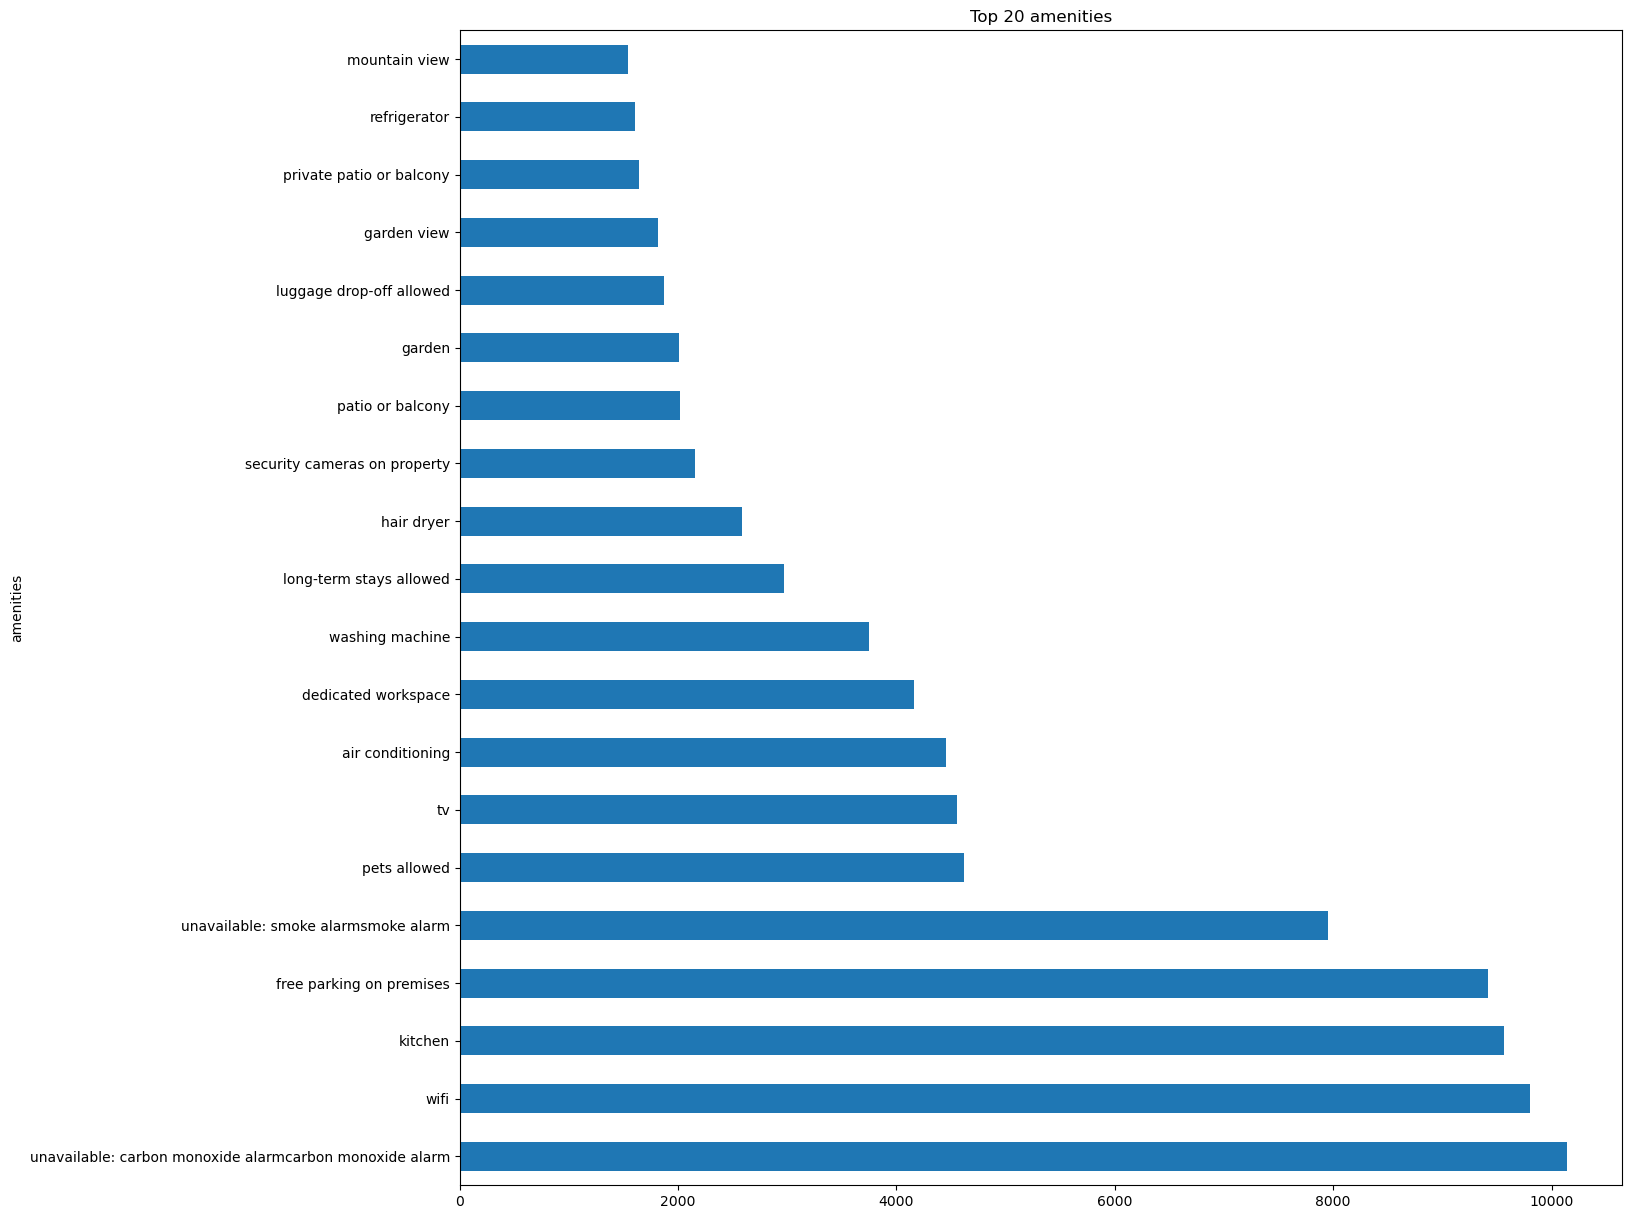

In [191]:
# amenities or features distribution
df['amenities'].str.lower().str.replace('[{}"]', '', regex=True).str.split(',').explode().value_counts().head(20).plot(
    kind='barh', title="Top 20 amenities", figsize=(15, 15))

* from the above graph we can see that among all features carbon monoxide alarm is the top feature among all listings

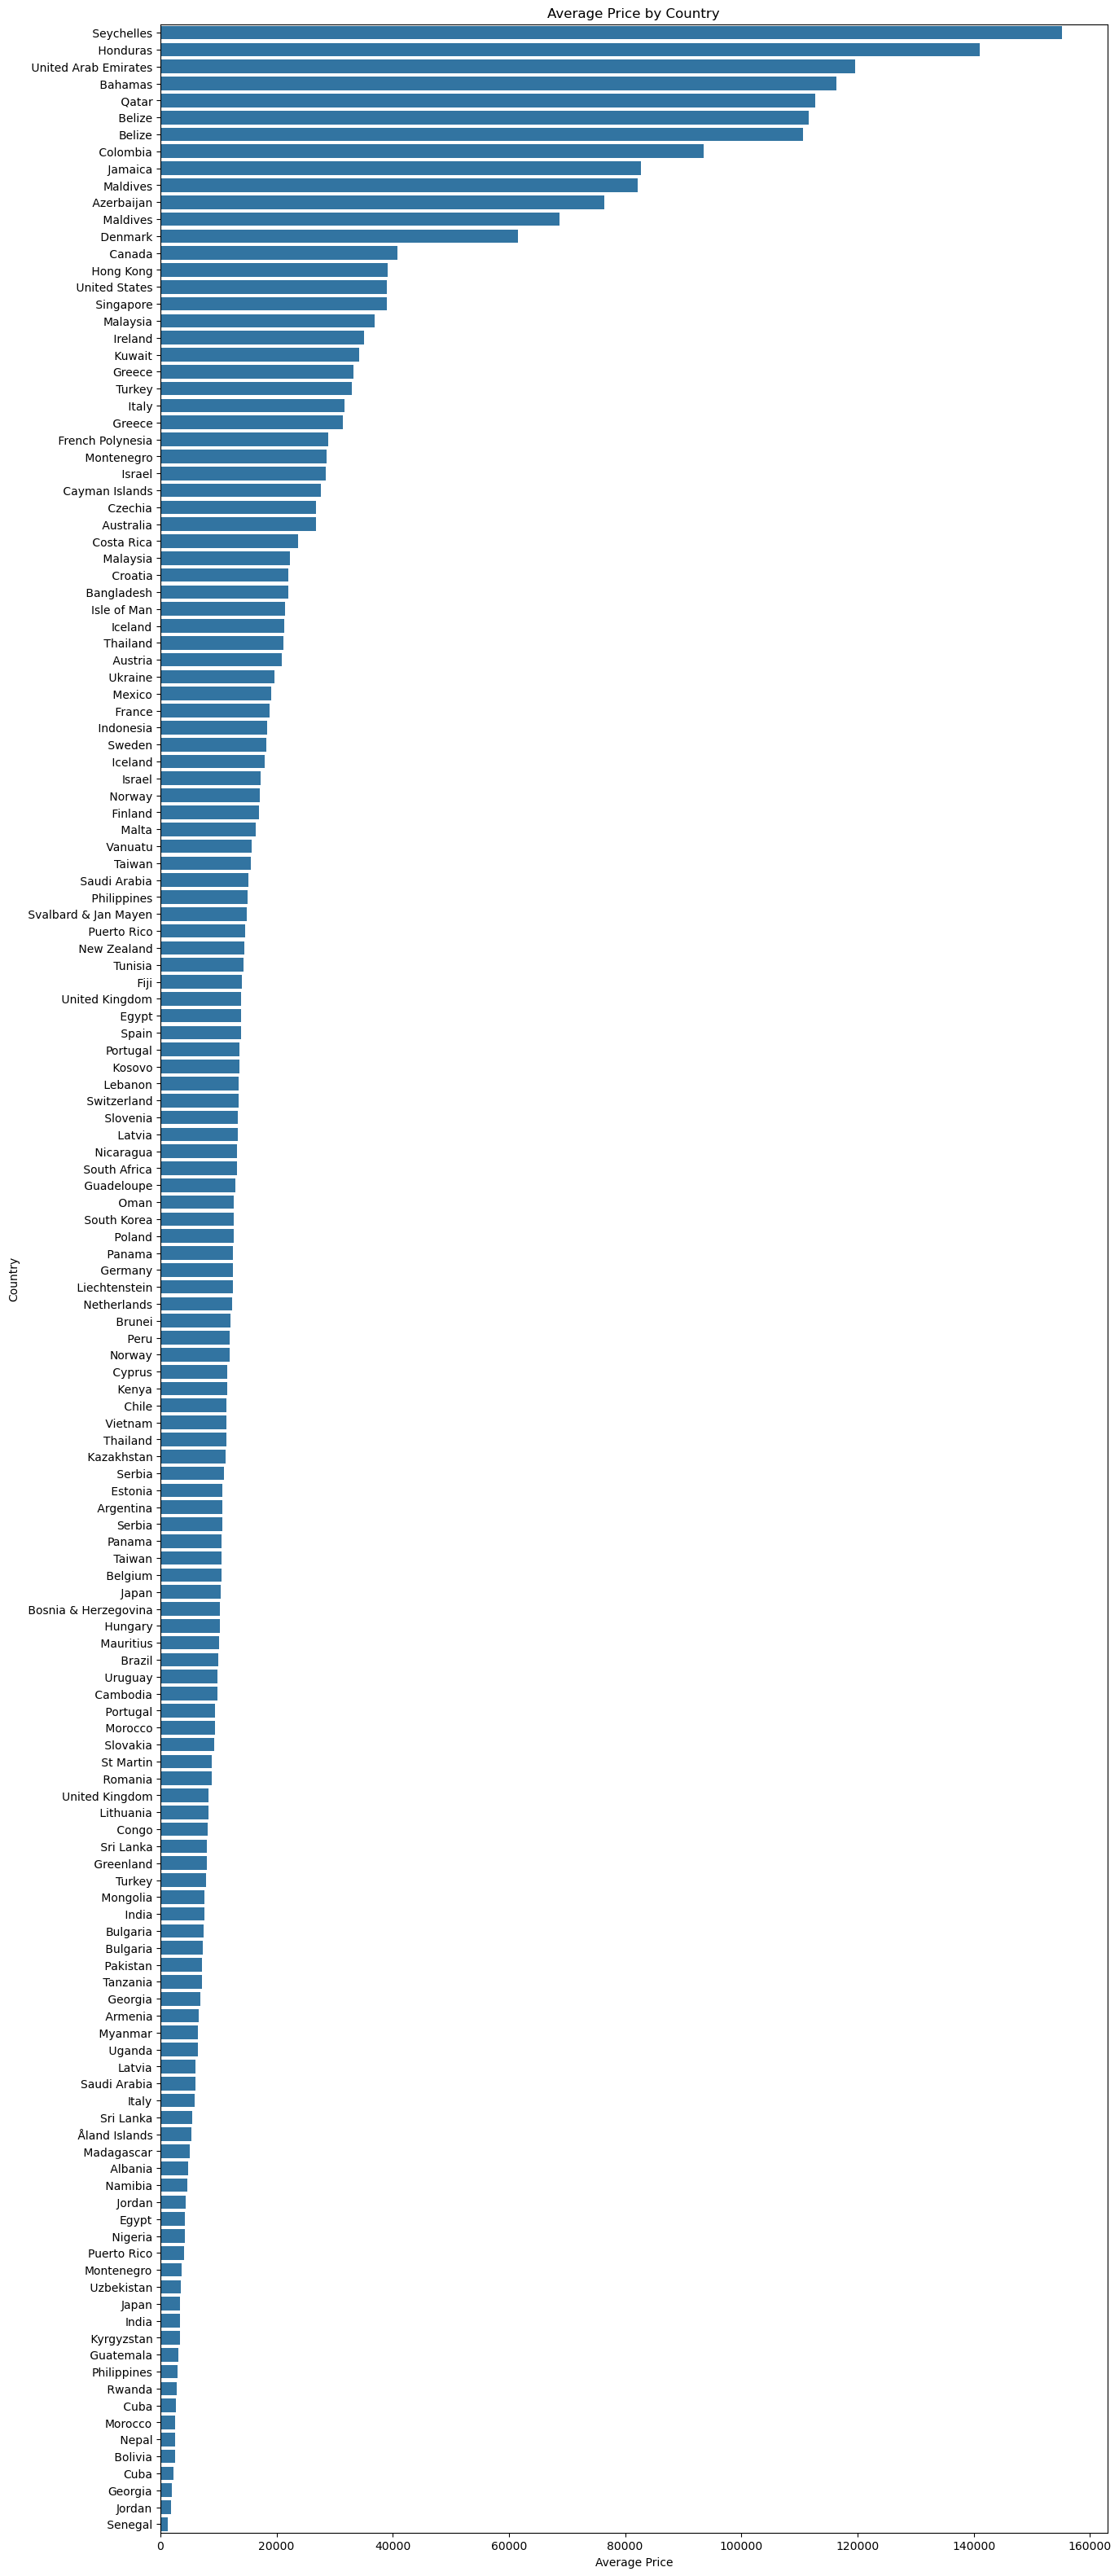

In [192]:
# Country vs Price
country_price = df.groupby(
    'country')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 40))
sns.barplot(x=country_price.values, y=country_price.index)
plt.title("Average Price by Country")
plt.xlabel("Average Price")
plt.ylabel("Country")
plt.show()

* Seychelles has the highest average price listing

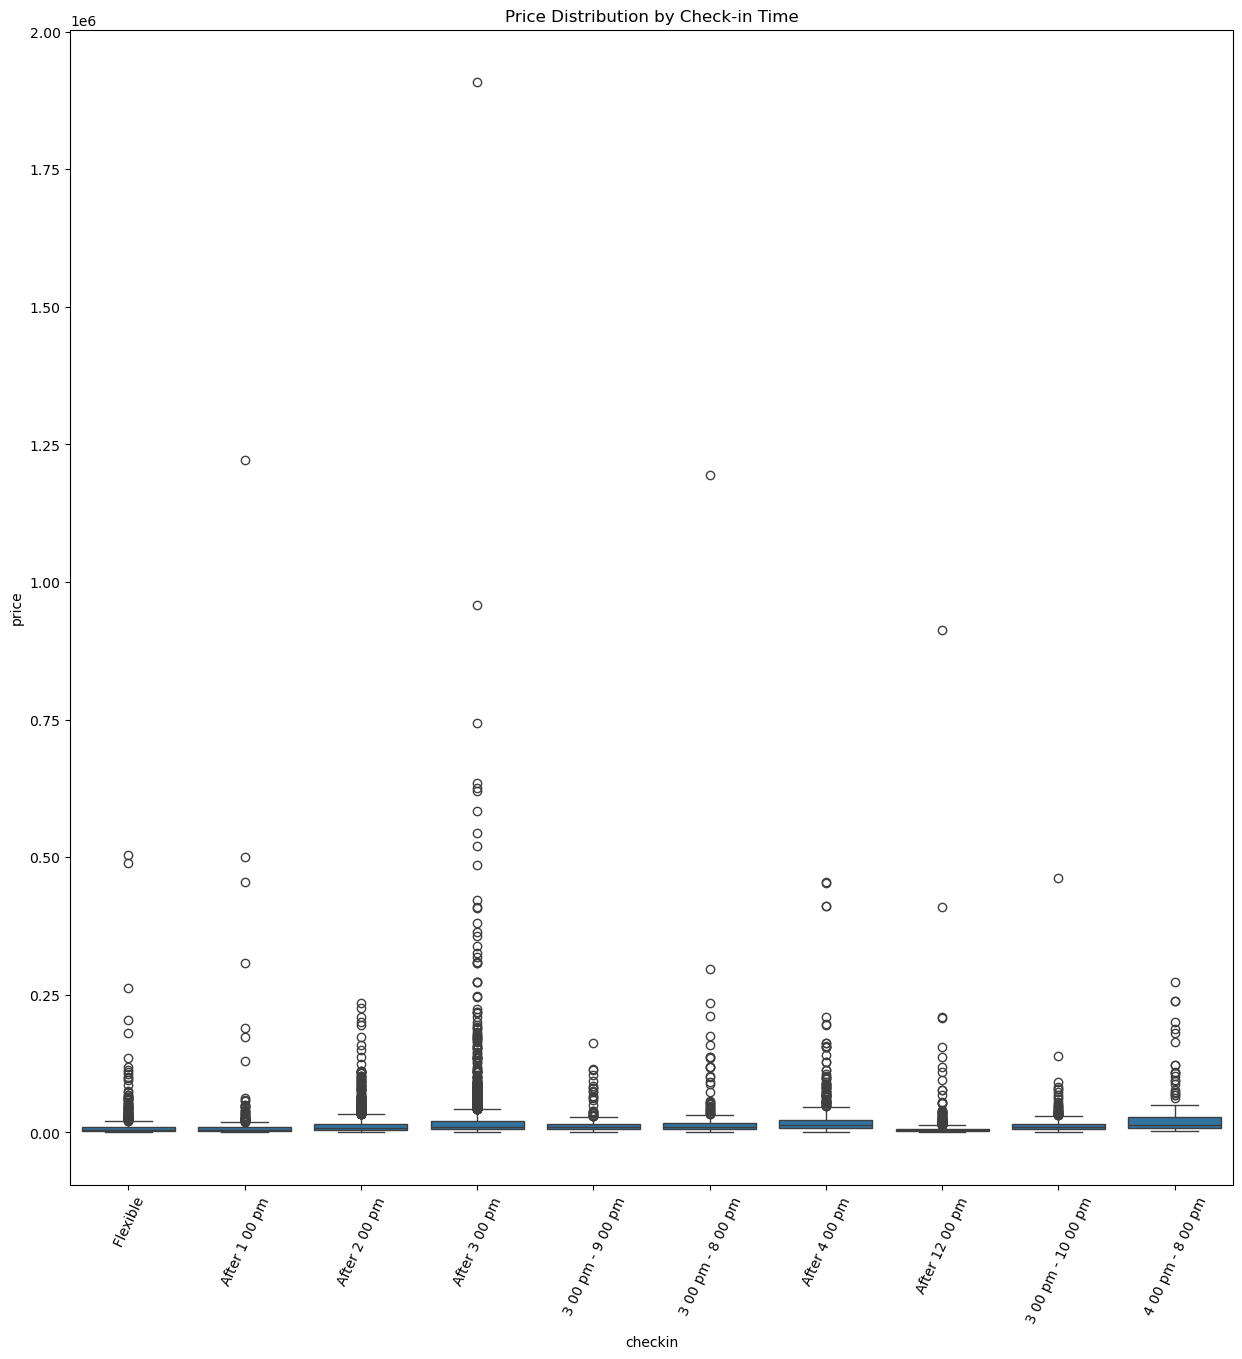

In [193]:
# Check-in / Check-out vs Price

top_checkins = df ['checkin'].value_counts().nlargest(10).index
filtered_df = df[df['checkin'].isin(top_checkins)]

plt.figure(figsize=(15, 15))
sns.boxplot(x='checkin', y='price', data=filtered_df)

plt.title("Price Distribution by Check-in Time")

plt.xticks(rotation=65)

plt.show()

* High value outliers lies "after 3:00 pm" check-in time. This indicates a small percentage of bookings can command exceptionally high prices.

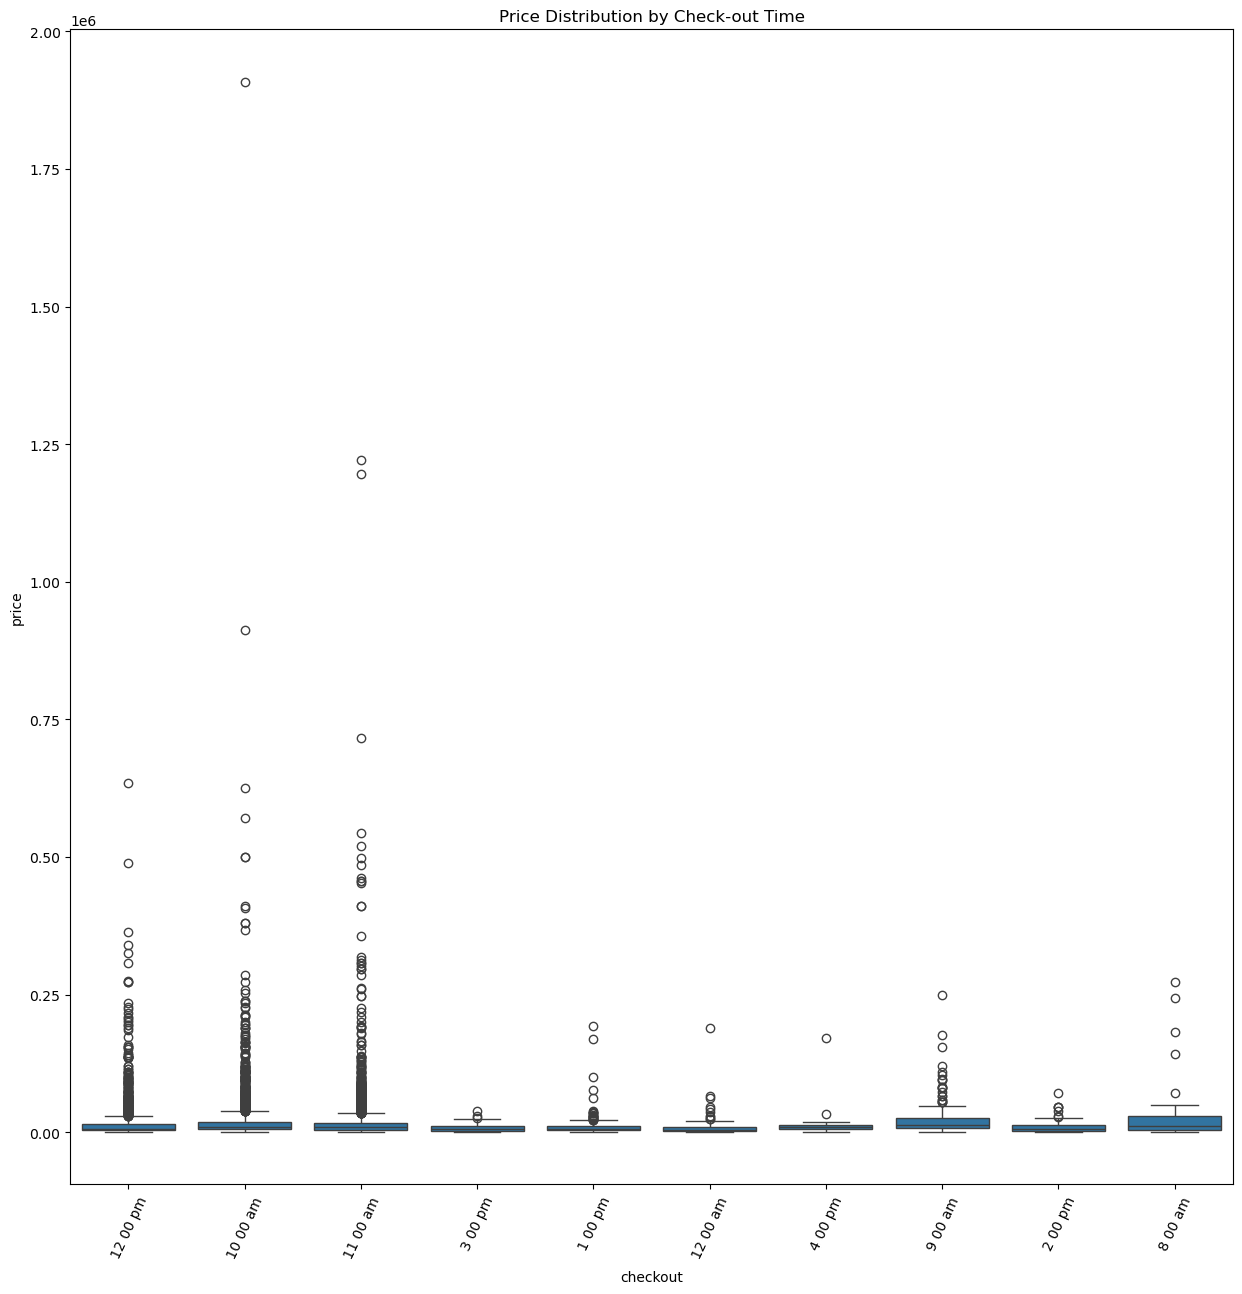

In [194]:
top_checkouts = df['checkout'].value_counts().nlargest(10).index
filtered_df = df[df['checkout'].isin(top_checkouts)]

plt.figure(figsize=(15, 15))
sns.boxplot(x='checkout', y='price', data=filtered_df)

plt.title("Price Distribution by Check-out Time")

plt.xticks(rotation=65)

plt.show()

* the most common checkout times 12 pm to 11 am exibhit the largest volume of bookings and also show a wide spread of prices due to these outliers.

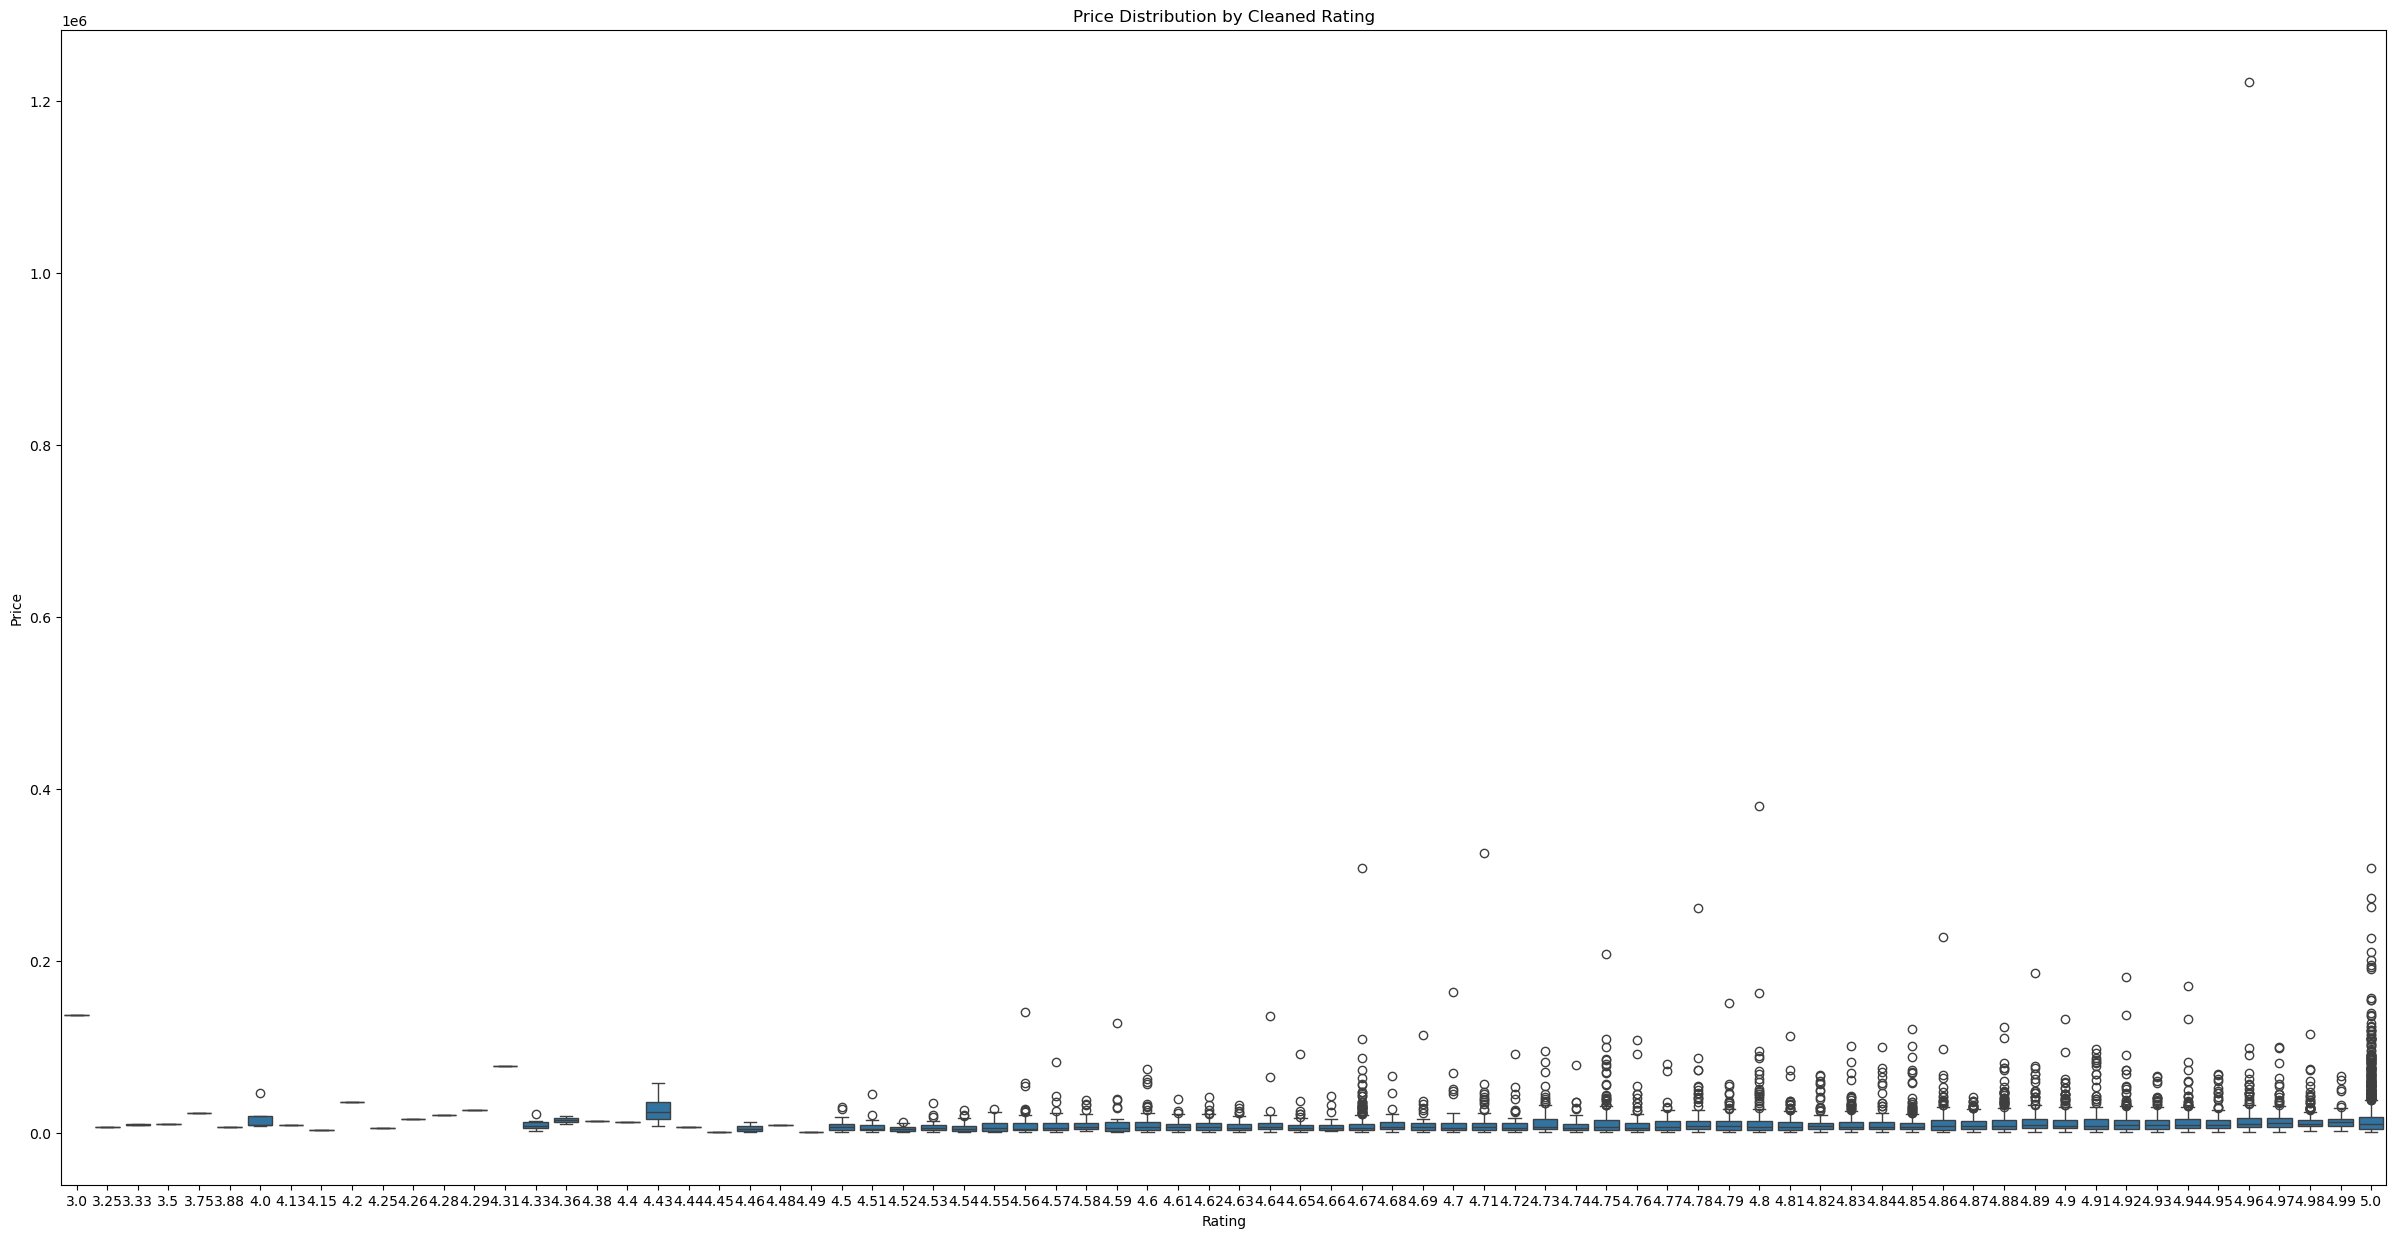

In [195]:
# Rating vs Price 

df['rating_cleaned'] = pd.to_numeric(df['rating'],errors='coerce')

plt.figure(figsize=(30,15))
sns.boxplot(x='rating_cleaned', y='price', data=df)
plt.title("Price Distribution by Cleaned Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()

* this indicates high price does not necessarily translate to high volume of ratings and vice versa.

/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 1019905 (\U000f9001) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989190 (\U000f1806) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989187 (\U000f1803) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989185 (\U000f1801) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


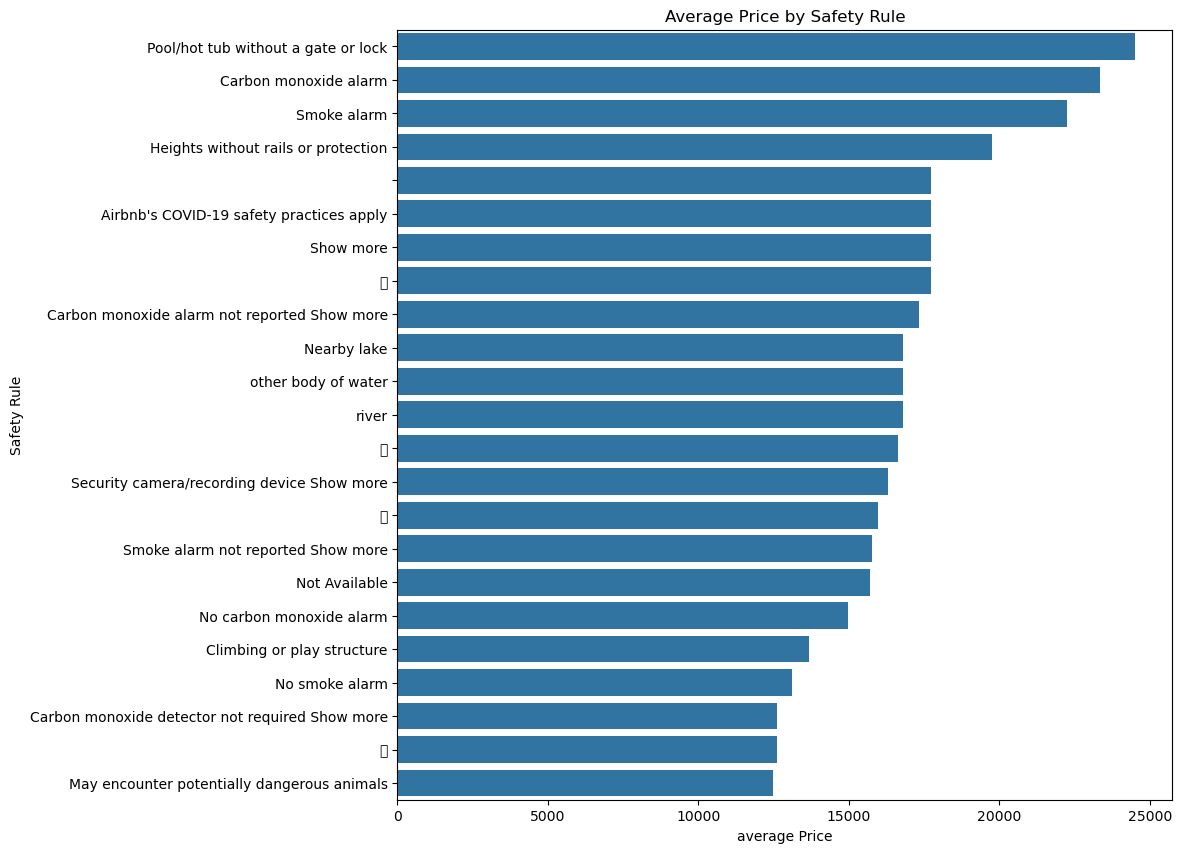

In [196]:
# Safety Rules vs Price
df_safety = df.copy()
df_safety['safety_rules'] = df_safety['safety_rules'].str.split(',')
df_safety = df_safety.explode("safety_rules")

df_safety['safety_rules'] = df_safety['safety_rules'].str.strip()


safety_price = df_safety.groupby('safety_rules')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 10))

sns.barplot(x=safety_price.values, y=safety_price.index)
plt.title("Average Price by Safety Rule")


plt.xlabel("average Price")

plt.ylabel("Safety Rule")
plt.show()

* this chart suggests amenities like ppols/hot tubs withour proper safety or the presence of smoke or carbon monoxide detector being associated with higher average prices, conversly absence of some safety features or presence of hurmful animals linked to lower average prices.

/opt/homebrew/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 989447 (\U000f1907) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


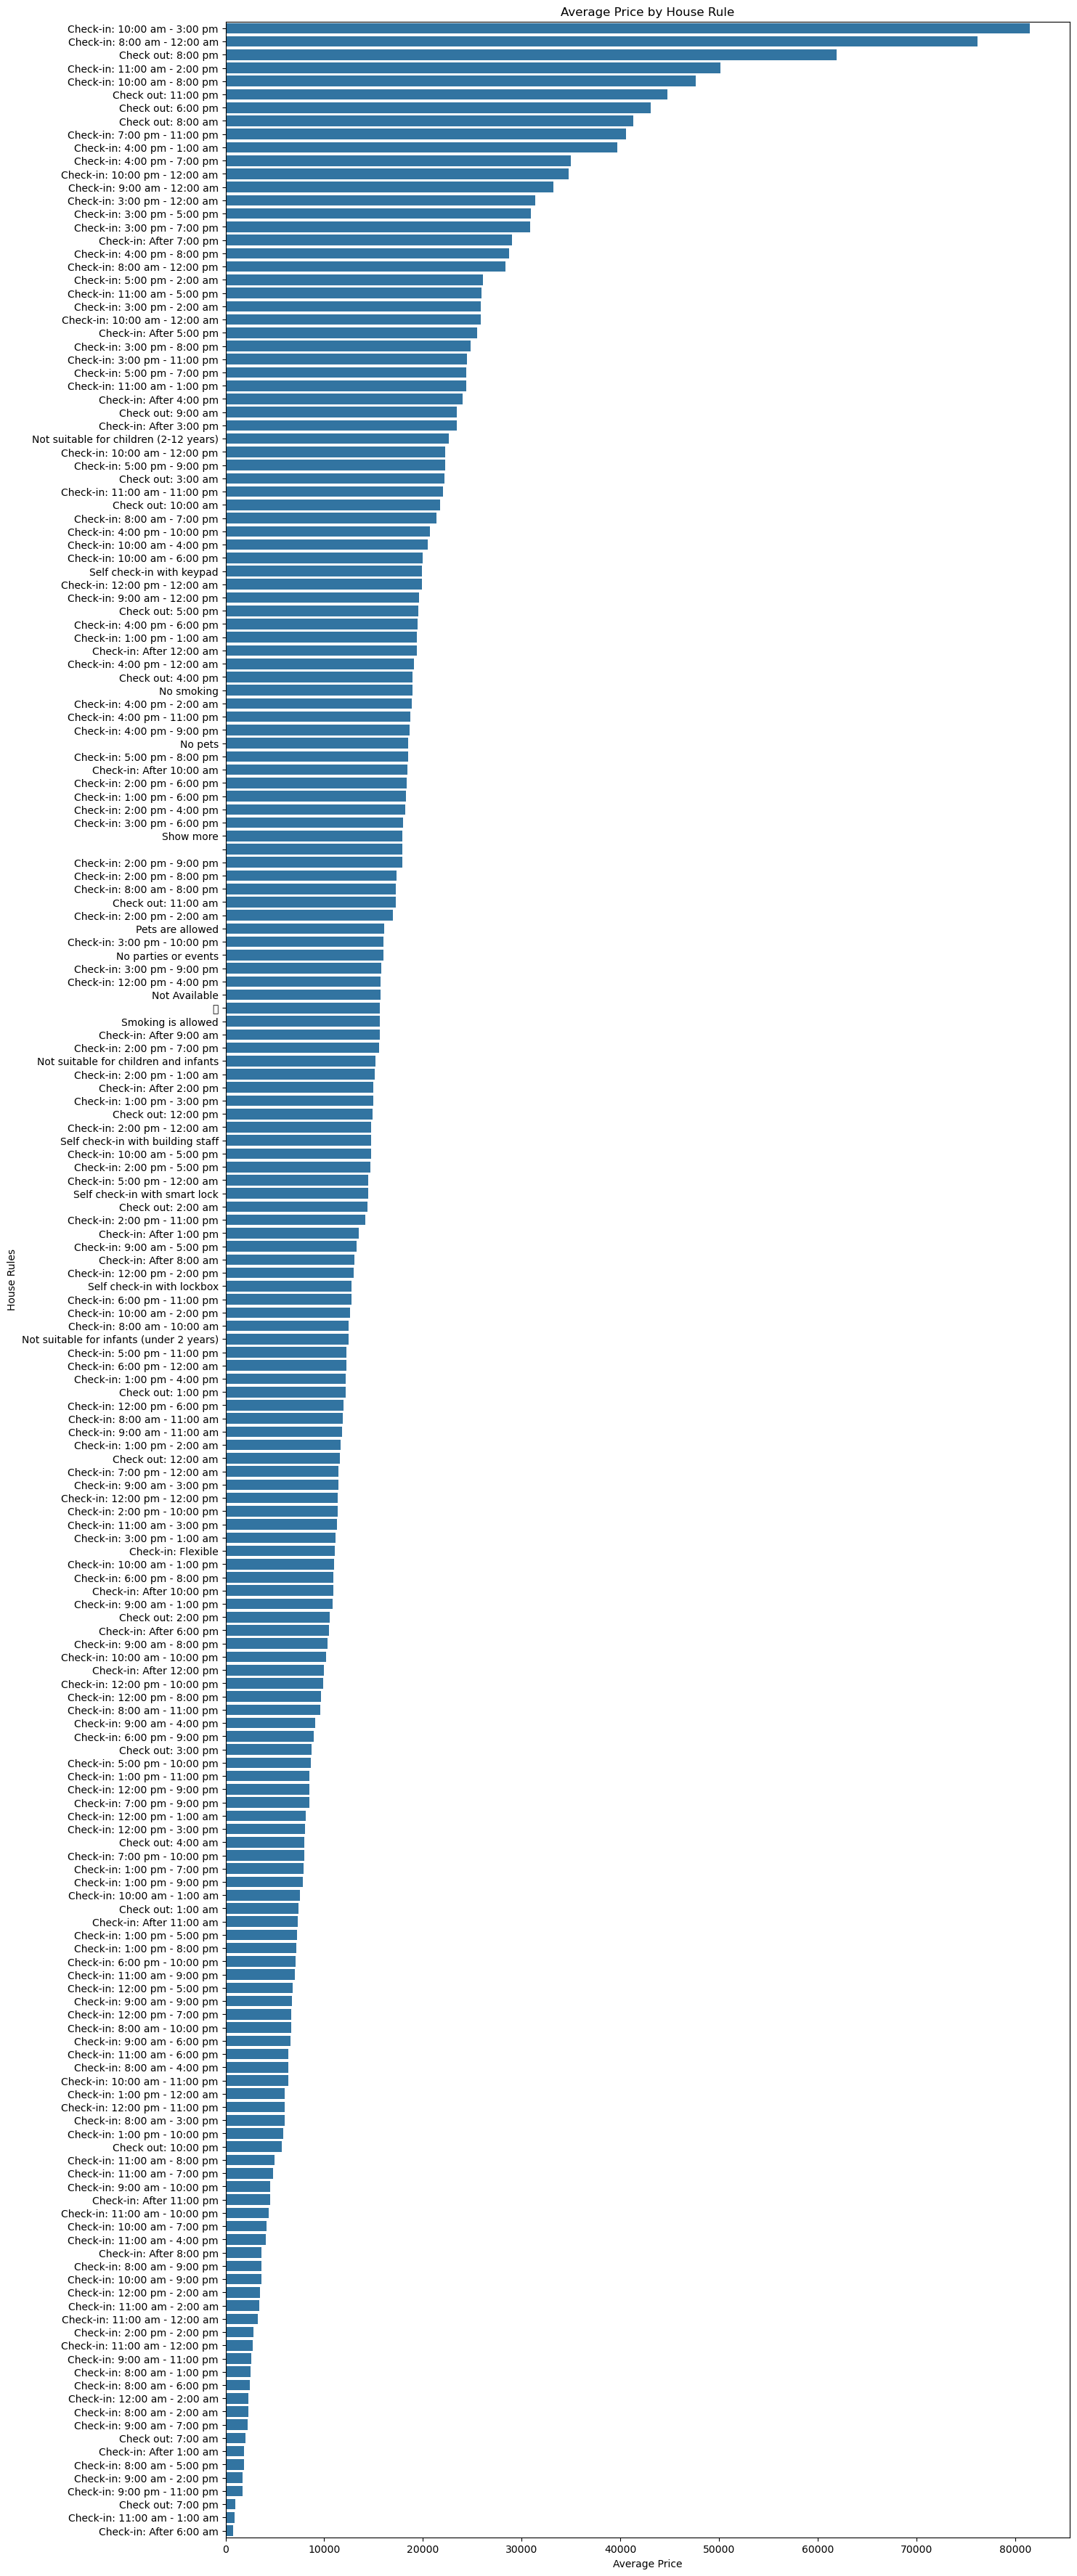

In [197]:
# House Rules vs Price

df.rename(columns={'hourse_rules':'house_rules'},inplace=True)


df_house = df.copy()

df_house['house_rules'] = df_house['house_rules'].str.split(',')

df_house=df_house.explode('house_rules')

df_house['house_rules'] = df_house['house_rules'].str.strip()


house_price=df_house.groupby('house_rules')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(15,45))

sns.barplot(x=house_price.values, y=house_price.index)

plt.title("Average Price by House Rule")

plt.xlabel("Average Price")

plt.ylabel("House Rules")
plt.show()

* this chart illustrates how different house rules specially checkin checkout times impacts the average price.

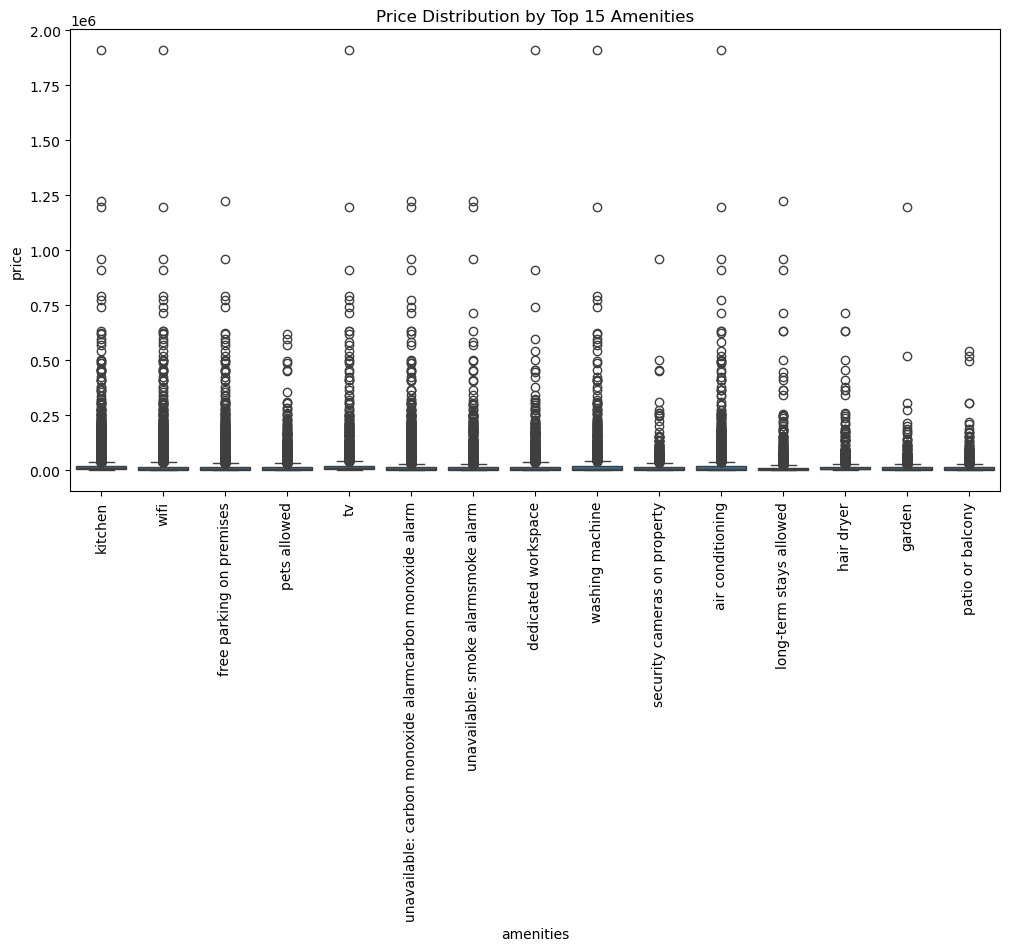

In [198]:
# Amenities vs Price
# Ensure all entries are strings first (avoids .str error)
df['amenities'] = df['amenities'].astype(str)

# Clean brackets and quotes, convert to lowercase
df['amenities'] = df['amenities'].str.replace(
    r'[\{\}"\[\]]', '', regex=True).str.lower()

# Split the string into a list of amenities
df['amenities'] = df['amenities'].str.split(',')

# Explode list into individual rows
amenities_exploded = df.explode('amenities')

# Strip whitespace from each amenity
amenities_exploded['amenities'] = amenities_exploded['amenities'].str.strip()

# Focus on top 15 most common amenities
top_amenities = amenities_exploded['amenities'].value_counts().nlargest(
    15).index
filtered_amenities = amenities_exploded[amenities_exploded['amenities'].isin(
    top_amenities)]

# Boxplot of price distribution for top 15 amenities
plt.figure(figsize=(12, 6))
sns.boxplot(x='amenities', y='price', data=filtered_amenities)
plt.xticks(rotation=90)
plt.title("Price Distribution by Top 15 Amenities")
plt.show()

* Kitchen, wifi, parking, pets allowed etc seem to have seem to have outliers reaching the highest price point

# Step 2: Data Cleaning

# Handling Missing Values

In [199]:
df = pd.read_csv('airbnb.csv')
df_cleaned = df.rename(columns={
    'toiles': 'toilets',
    'hourse_rules': 'house_rules'
})
df_cleaned.to_csv('airbnb_feature_renamed.csv',index=False)

In [200]:
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values>0]
print(f"missing values by column: {missing_values}")

missing values by column: host_name       8
checkin       800
checkout     2450
dtype: int64


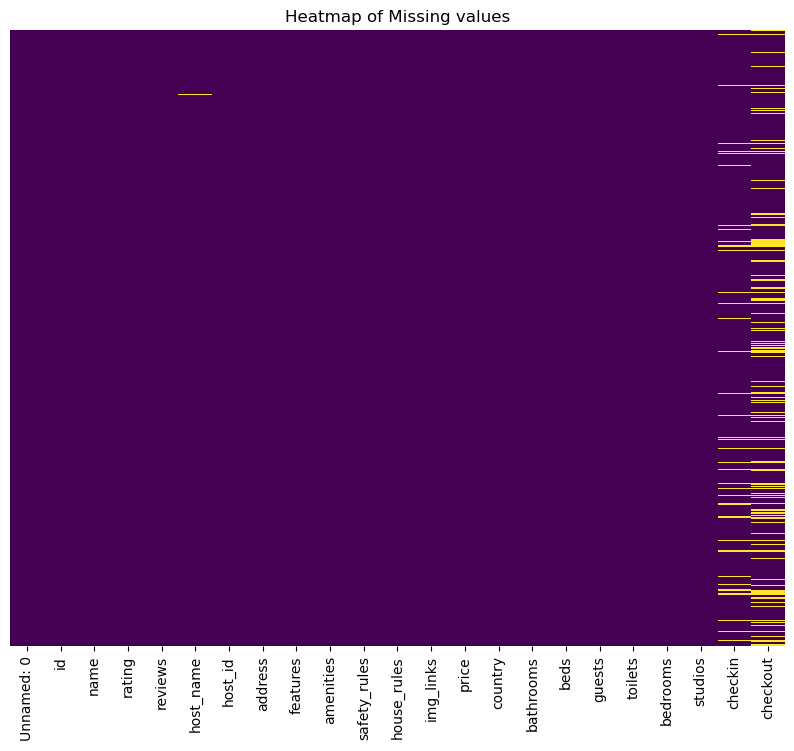

In [201]:
plt.figure(figsize=(10,8))

sns.heatmap(df_cleaned.isnull(),cbar=False,cmap='viridis',yticklabels=False)

plt.title("Heatmap of Missing values")
plt.show()

* from the heatmap it can be seen that missing values lies in the features such as checkin,checkout,host_id, among these checkout has the highest number of missing values.

In [202]:
# as host name column missing only 8 values so it is not that critical we can handle this values by filling with 'unknown' or mode 

df_cleaned['host_name'] = df_cleaned['host_name'].fillna(
    df_cleaned['host_name'].mode()[0])

In [203]:
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(f"missing values by column: \n {missing_values}")

missing values by column: 
 checkin      800
checkout    2450
dtype: int64


In [204]:
# checkin has 800 missing values 

df_cleaned['checkin'] = df_cleaned['checkin'].fillna('Unknown')

In [205]:
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(f"missing values by column: \n {missing_values}")

missing values by column: 
 checkout    2450
dtype: int64


In [206]:
# checkouts has the highest missing values (2450) as price varies during checkout times we can't discard or drop those missing values the most we can do that we can fill those values with 'unknown'
df_cleaned['checkout'] = df_cleaned['checkout'].fillna('Unknown')

In [207]:
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(f"missing values by column: \n {missing_values}")

missing values by column: 
 Series([], dtype: int64)


#  Detecting and Removing Outliers

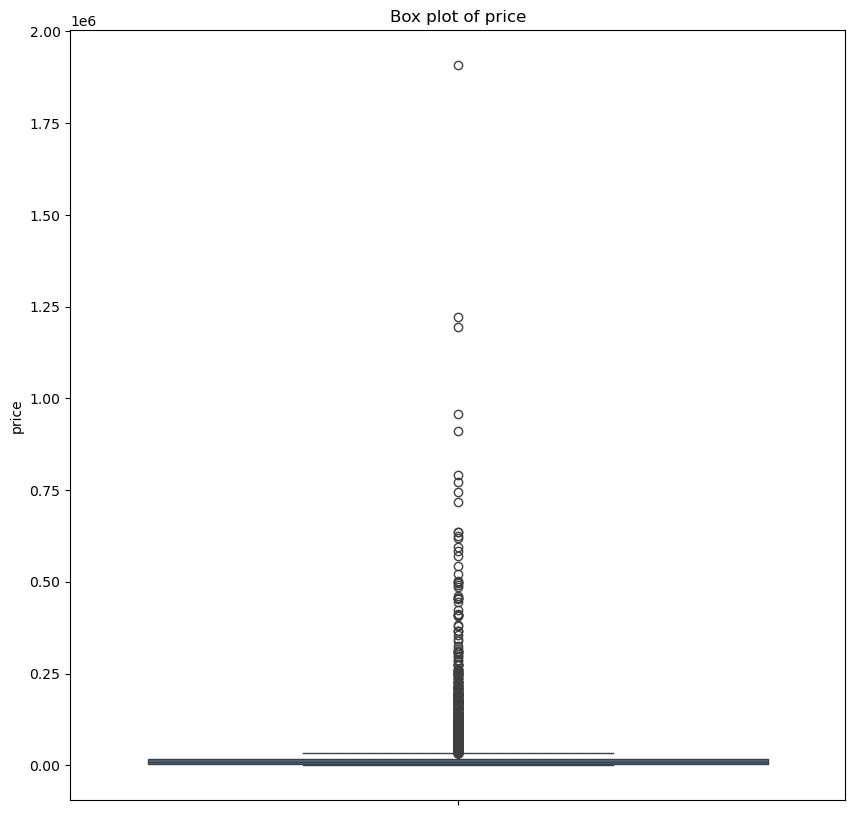

In [208]:
# visualization of outliers:
plt.figure(figsize=(10,10))
sns.boxplot(y=df_cleaned['price'])
plt.title("Box plot of price")
plt.show()

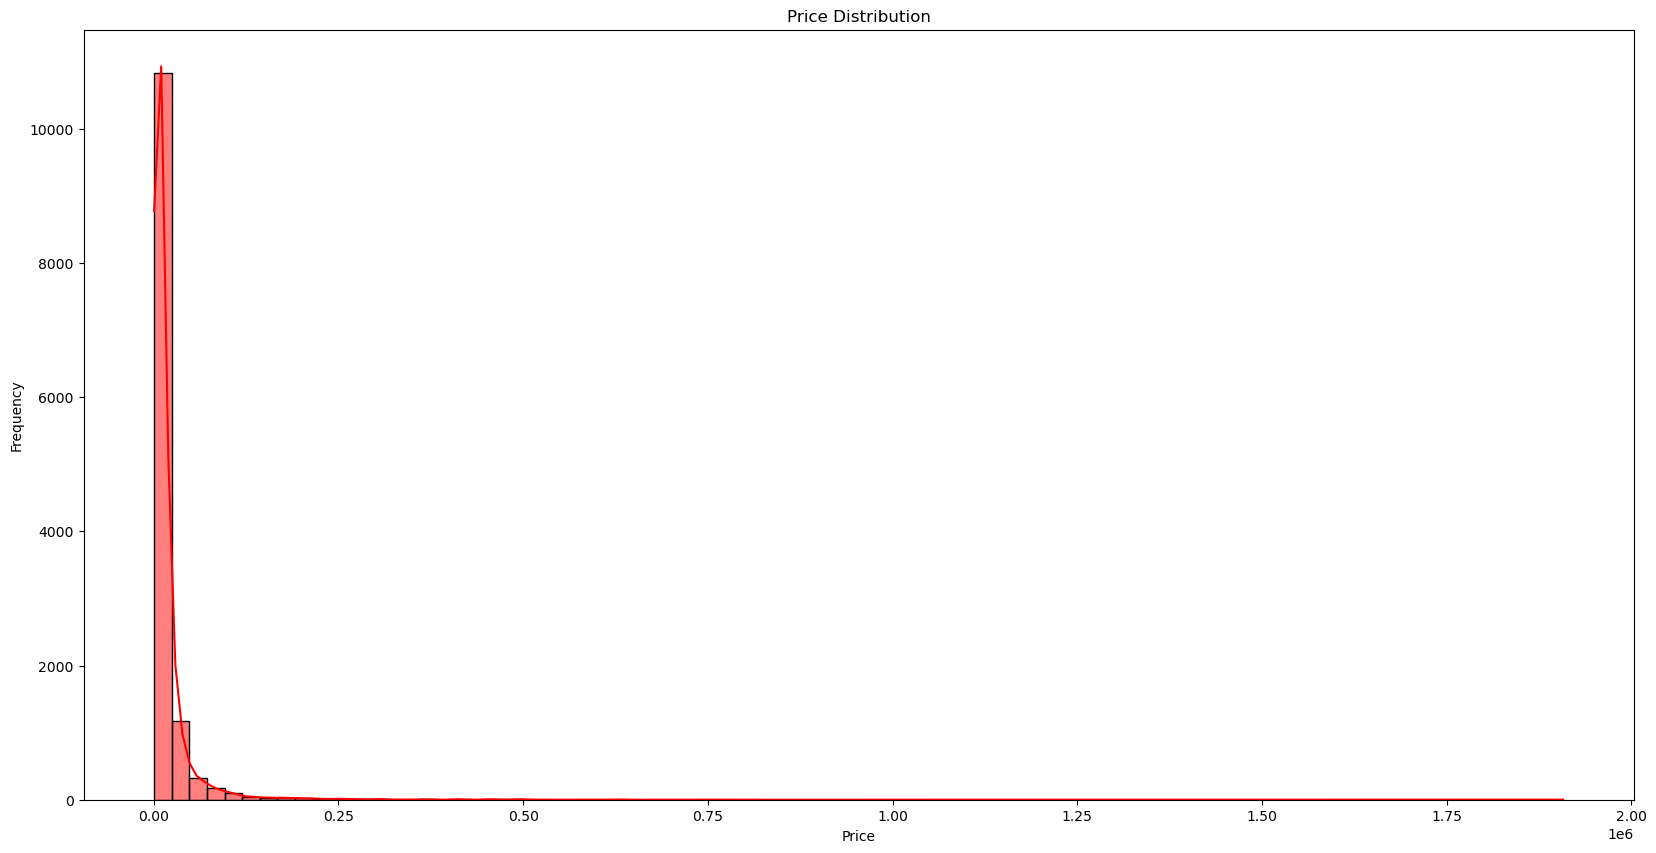

In [209]:
# visualization of outliers:
plt.figure(figsize=(20, 10))
sns.histplot(df_cleaned['price'],bins=80,kde=True,color='r')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

* rightly skewed suggests a few very expensive listings.

In [210]:
# removing outliers
Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)

IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_no_outliers = df_cleaned[(df_cleaned['price'] >= lower_bound) & (df_cleaned['price'] <= upper_bound)]

print("Original shape: ",df_cleaned.shape)
print("After removing outliers shape: ", df_no_outliers.shape)

Original shape:  (12805, 23)
After removing outliers shape:  (11532, 23)


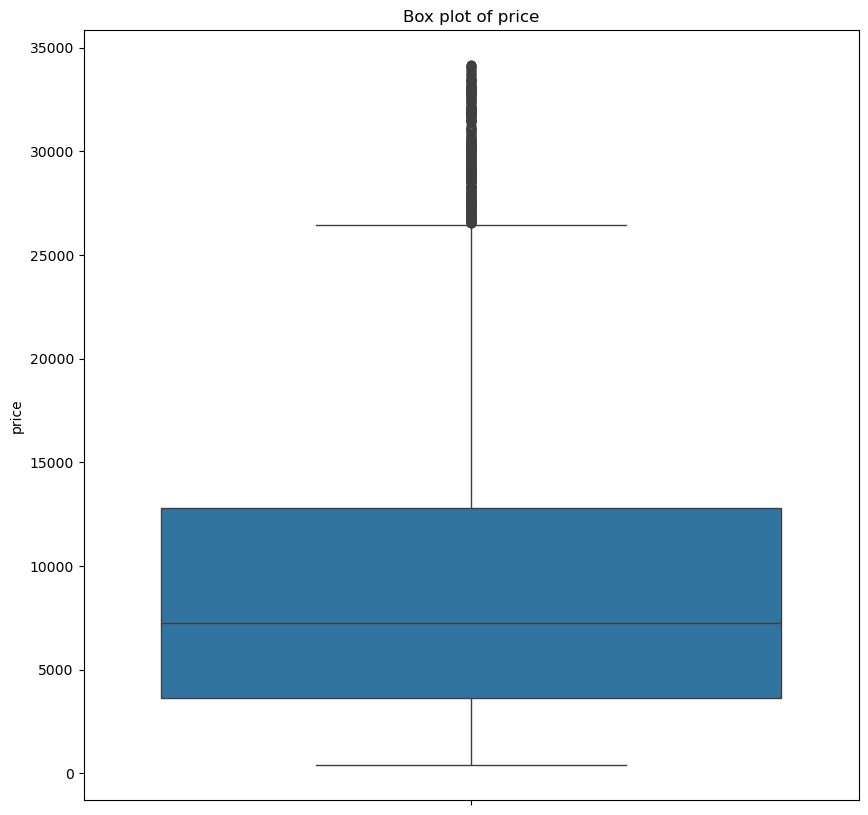

In [211]:
# visualization  after removing outliers:
plt.figure(figsize=(10, 10))
sns.boxplot(y=df_no_outliers['price'])
plt.title("Box plot of price")
plt.show()

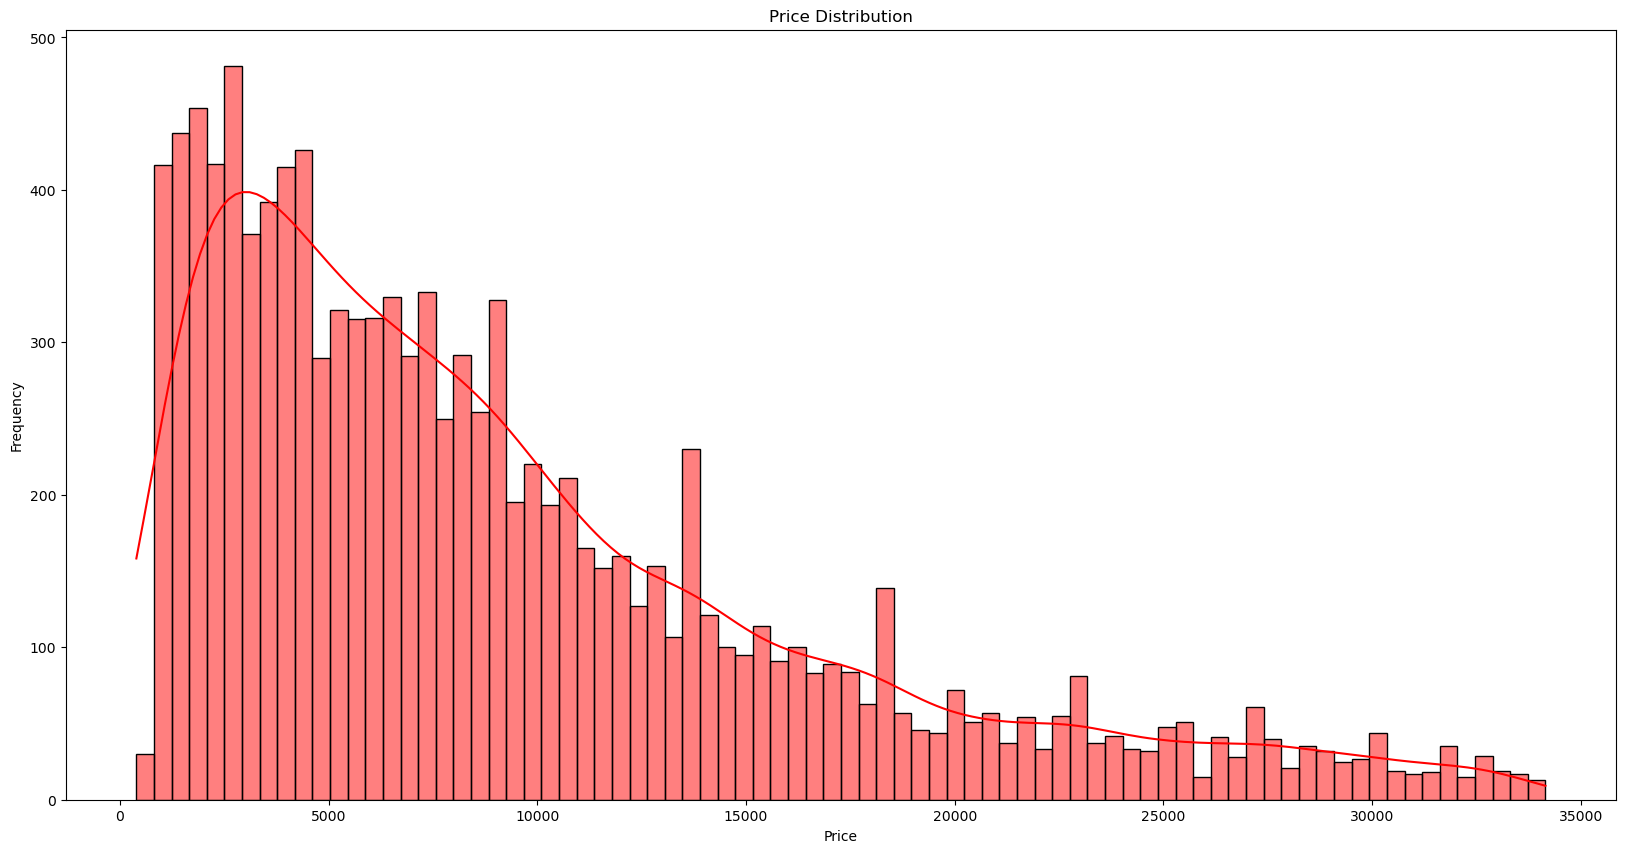

In [212]:
# visualization after removing  outliers:
plt.figure(figsize=(20, 10))
sns.histplot(df_no_outliers['price'], bins=80, kde=True, color='r')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [213]:
# adjusting outliers:
# Cap prices to IQR range

df_adjusted = df_cleaned.copy()

df_adjusted['price'] = df_adjusted['price'].clip(lower=lower_bound,upper=upper_bound)

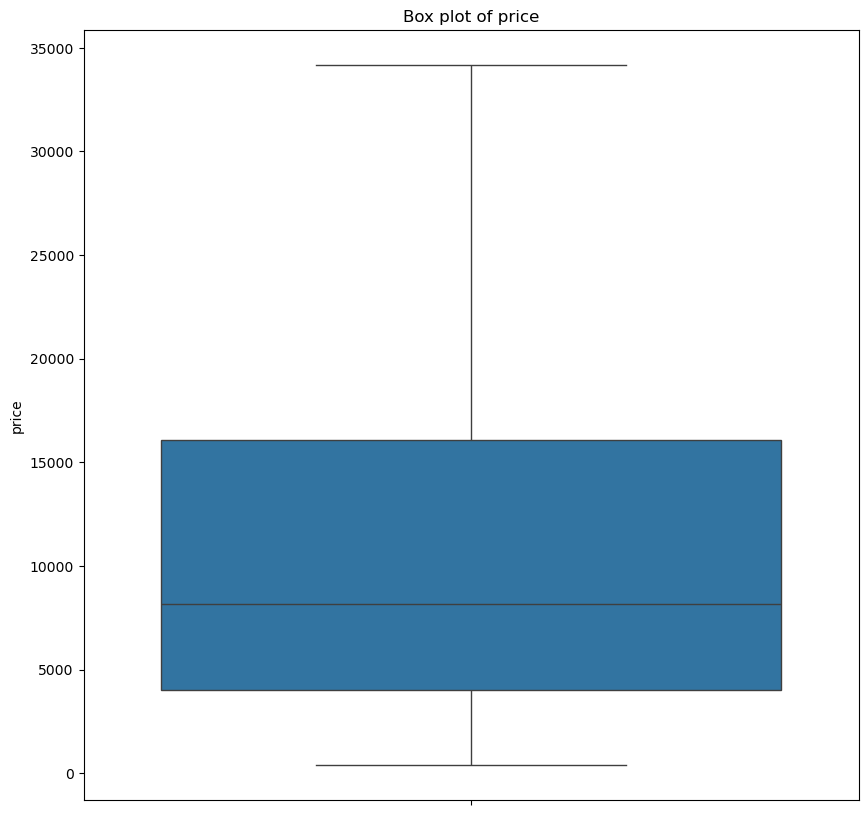

In [214]:
# visualization  after adjusting outliers:
plt.figure(figsize=(10, 10))
sns.boxplot(y=df_adjusted['price'])
plt.title("Box plot of price")
plt.show()

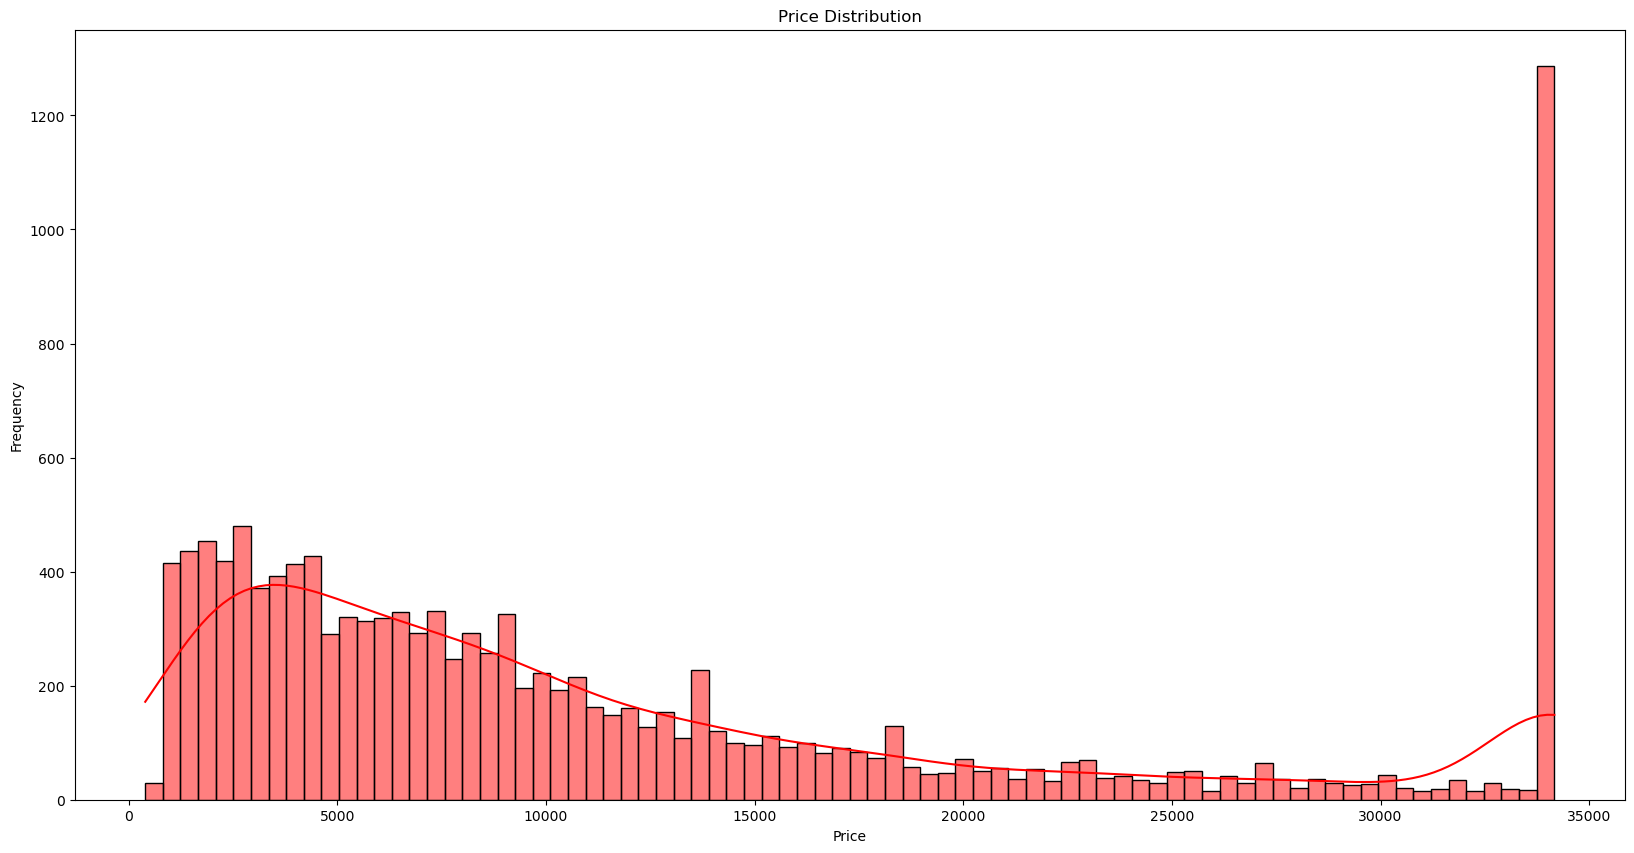

In [215]:
# visualization after adjusting  outliers:
plt.figure(figsize=(20, 10))
sns.histplot(df_adjusted['price'], bins=80, kde=True, color='r')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

* removing outliers is used when we need cleaned data and we are okay with loosing some rows, but we use adjusted when outliers are valid but needed to be softened 

# Conversion of Categorical Features

In [216]:
df_cleaned['rating'] = pd.to_numeric(df_cleaned['rating'], errors='coerce')

# Convertion of 'safety_rules' and 'house_rules' to lists (if comma-separated strings)
df_cleaned['safety_rules'] = df_cleaned['safety_rules'].str.split(',')
df_cleaned['house_rules'] = df_cleaned['house_rules'].str.split(',')

# Clean 'amenities' and 'features'
df_cleaned['amenities'] = df_cleaned['amenities'].str.replace(
    r'[\[\]\{\}"\']', '', regex=True).str.lower().str.split(',')
df_cleaned['features'] = df_cleaned['features'].str.replace(
    r'[\[\]\{\}"\']', '', regex=True).str.lower().str.split(',')

In [217]:
# Exploding Multi-Value Columns
# We’ll convert list-like columns (safety_rules, house_rules, amenities, features) into a format suitable for one-hot encoding:
# Explode and rejoin after encoding

def one_hot_explode(df, column):
    exploded = df[['id', column]].explode(column)
    exploded[column] = exploded[column].str.strip()
    dummies = pd.get_dummies(exploded[column], prefix=column)
    result = exploded[['id']].join(dummies).groupby('id').sum().reset_index()
    return result


# Apply to each multi-value column
rules_encoded = one_hot_explode(df_cleaned, 'safety_rules')
house_encoded = one_hot_explode(df_cleaned, 'house_rules')
amenities_encoded = one_hot_explode(df_cleaned, 'amenities')
features_encoded = one_hot_explode(df_cleaned, 'features')

In [218]:
# Encode Single-Value Categorical Columns (e.g., country, checkin, checkout)
one_hot_simple = pd.get_dummies(
    df_cleaned[['country', 'checkin', 'checkout']], drop_first=True)

In [219]:
# Merge Everything Back
# Join all together on 'id'
df_encoded = df_cleaned.merge(rules_encoded, on='id', how='left')\
                       .merge(house_encoded, on='id', how='left')\
                       .merge(amenities_encoded, on='id', how='left')\
                       .merge(features_encoded, on='id', how='left')\
                       .join(one_hot_simple)

# Fill any missing dummy values with 0
df_encoded.fillna(0, inplace=True)

In [220]:
# Optional: Drop Original Categorical Columns 
columns_to_drop = ['country', 'checkin', 'checkout',
                   'safety_rules', 'house_rules', 'amenities', 'features']
df_encoded.drop(columns=columns_to_drop, inplace=True)

In [221]:
# Save the Encoded Data:
df_encoded.to_csv('airbnb one hot encoded data.csv', index=False)

# Feature Scaling suitable for Artificial Neural Network

In [222]:
# standardization 
from sklearn.preprocessing import StandardScaler
num_features = ['bathrooms','beds','bedrooms','guests','studios','toilets','price']
scaler=StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[num_features] = scaler.fit_transform(df_scaled[num_features])
# print(df_scaled)

* this rescales to have features mean=0 and standard deviation =1 and this is used most ML/ANN models

In [223]:
# svaing the scaled dataset
df_scaled.to_csv('airbnb_scaled_data.csv', index=False)

# Step 3: Model Creation:

In [224]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [225]:
# Select relevant features (exclude target from input!)
features = ['bathrooms', 'beds', 'bedrooms', 'guests', 'studios', 'toilets']
target = 'price'

# Filter out extreme price outliers (optional but recommended)
df_scaled = df_scaled[df_scaled['price']
                      < df_scaled['price'].quantile(0.99)]

# Split into X and y
X = df_scaled[features]
y = df_scaled[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Clean numeric columns
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = pd.to_numeric(y_train, errors='coerce').fillna(0)
y_test = pd.to_numeric(y_test, errors='coerce').fillna(0)

# Feature scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Target scaling (optional, for stability)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [226]:
# Define the ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # No activation for regression
])

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [227]:
history = model.fit(X_train_scaled, y_train_scaled,
                    validation_data=(X_test_scaled, y_test_scaled),
                    epochs=100,
                    batch_size=32,
                    verbose=1)

Epoch 1/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - loss: 0.8206 - mae: 0.4935 - val_loss: 0.6452 - val_mae: 0.4761
Epoch 2/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.6781 - mae: 0.4657 - val_loss: 0.6303 - val_mae: 0.4504
Epoch 3/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - loss: 0.7493 - mae: 0.4818 - val_loss: 0.6348 - val_mae: 0.4466
Epoch 4/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - loss: 0.7311 - mae: 0.4771 - val_loss: 0.6429 - val_mae: 0.4531
Epoch 5/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.7071 - mae: 0.4681 - val_loss: 0.6333 - val_mae: 0.4739
Epoch 6/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 0.7156 - mae: 0.4796 - val_loss: 0.6565 - val_mae: 0.4484
Epoch 7/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 0.7054 - mae: 0.4659 - val_loss: 0.6251 - val_mae: 0.4481
Epoch 8/100
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.7574 - mae: 0.4832 - val_loss: 0.6320 - val_mae: 0.4372
Epoch 9/100
317/317 ━━━━━━━━━━━━

In [228]:
# Predict on test set
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled)

# Evaluation metrics
print("MSE:", mean_squared_error(y_test_original, y_pred))
print("MAE:", mean_absolute_error(y_test_original, y_pred))
print("R² Score:", r2_score(y_test_original, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step
MSE: 0.13412512138997598
MAE: 0.2049912418931183
R² Score: 0.21840427320760147


- MSE	0.1311	shows moderate error, the lower the better.
- MAE	0.2021	it tells on average predictions are off by 0.2 units.
- R²	0.2362	it demonstrates around 24% of price variation.

# Step 4: Accuracy Improvement

In [229]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

#  Feature selection
features = ['bathrooms', 'beds', 'bedrooms', 'guests', 'studios', 'toilets']
target = 'price'

#  Remove extreme outliers
df_scaled = df_scaled[df_scaled['price'] < df_scaled['price'].quantile(0.99)]

#  Create price bins (3 classes)
df_scaled['price_bin'] = pd.qcut(df_scaled['price'], q=3, labels=[
                                 'low', 'medium', 'high'])

#  Inputs and target
X = df_scaled[features]
y = df_scaled['price_bin']

#  Encode class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # converts labels to 0, 1, 2
y_cat = to_categorical(y_encoded)

#  Train-test split
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, random_state=42)

#  Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Define ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 categories: low, medium, high
])

#  Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#  Train the model
history = model.fit(X_train_scaled, y_train_cat,
                    validation_data=(X_test_scaled, y_test_cat),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

#  Predict and Evaluate
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

#  Classification metrics
print("\n📊 Classification Report:\n")
print(classification_report(y_true_classes,
      y_pred_classes, target_names=label_encoder.classes_))


Epoch 1/50


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4798 - loss: 1.0271 - val_accuracy: 0.4861 - val_loss: 1.0060
Epoch 2/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.5156 - loss: 0.9770 - val_accuracy: 0.4904 - val_loss: 1.0012
Epoch 3/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.5084 - loss: 0.9804 - val_accuracy: 0.4940 - val_loss: 1.0016
Epoch 4/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - accuracy: 0.5268 - loss: 0.9650 - val_accuracy: 0.4968 - val_loss: 1.0021
Epoch 5/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.5230 - loss: 0.9677 - val_accuracy: 0.4972 - val_loss: 0.9988
Epoch 6/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.5208 - loss: 0.9624 - val_accuracy: 0.4976 - val_loss: 1.0011
Epoch 7/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.5242 - loss: 0.9592 - val_accuracy: 0.5000 - val_loss: 0.9967
Epoch 8/50
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.5153 - loss: 0.9700 - val_accuracy:

accuracy: 0.5215 → Training accuracy: ~52.15%

loss: 0.9535 → Training loss (categorical cross-entropy)

val_accuracy: 0.5040 → Validation accuracy: ~50.40%

val_loss: 0.9922 → Validation loss

the model is learning but training and validation accuracy are low, suggesting the model might be underfitting(not learning enough), facing noisy dataset or it has few informative features.

# accuracy,precision, recall, F1-score and confusion matrix

Generating Confusion Matrix...


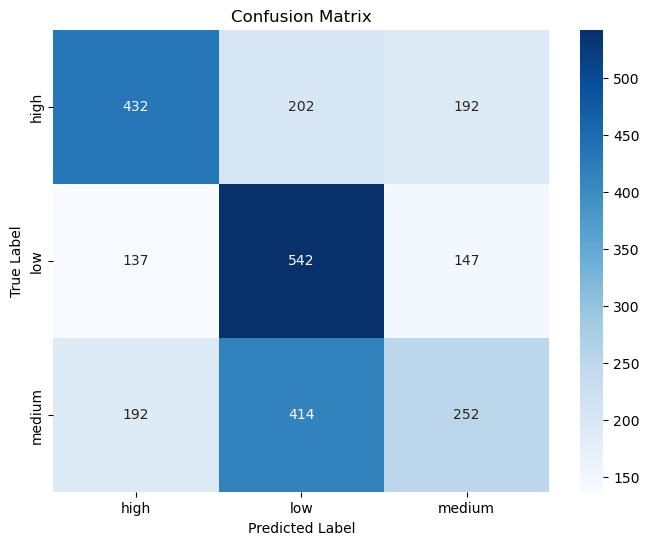

Confusion Matrix plot displayed.
------------------------------

Generating Classification Report (Accuracy, Precision, Recall, F1-score)...
              precision    recall  f1-score   support

        high       0.57      0.52      0.54       826
         low       0.47      0.66      0.55       826
      medium       0.43      0.29      0.35       858

    accuracy                           0.49      2510
   macro avg       0.49      0.49      0.48      2510
weighted avg       0.49      0.49      0.48      2510

Classification Report displayed.


In [230]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np  # Needed for np.argmax

# 1. Confusion Matrix Code
print("Generating Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,  # Labels for predicted classes
            yticklabels=label_encoder.classes_)  # Labels for actual classes
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
print("Confusion Matrix plot displayed.")
print("-" * 30)

# 2. Accuracy, Precision, Recall, and F1-score (Classification Report)
print("\nGenerating Classification Report (Accuracy, Precision, Recall, F1-score)...")
print(classification_report(y_true_classes,
      y_pred_classes, target_names=label_encoder.classes_))
print("Classification Report displayed.")

* out of all actual high prices the model correctly indentified 441, but misclassified 191 as low and 198 as medium 
* out of all actual low prices the model correctly indentified 560, but misclassified 115 as high and 130 as medium 
* out of all actual medium prices the model correctly indentified 265, but misclassified 157 as high and 428 as low

- this model has overall accuracy of 51%, and shows the ability of predicting high and low prices correctly but it struggles predicting medium prices correctly. The medium class has very lwo precision and recall which indicates it frequently misclassifies true medium properties and also make many incorrect predictions of medium.

# AUC-ROC Curve

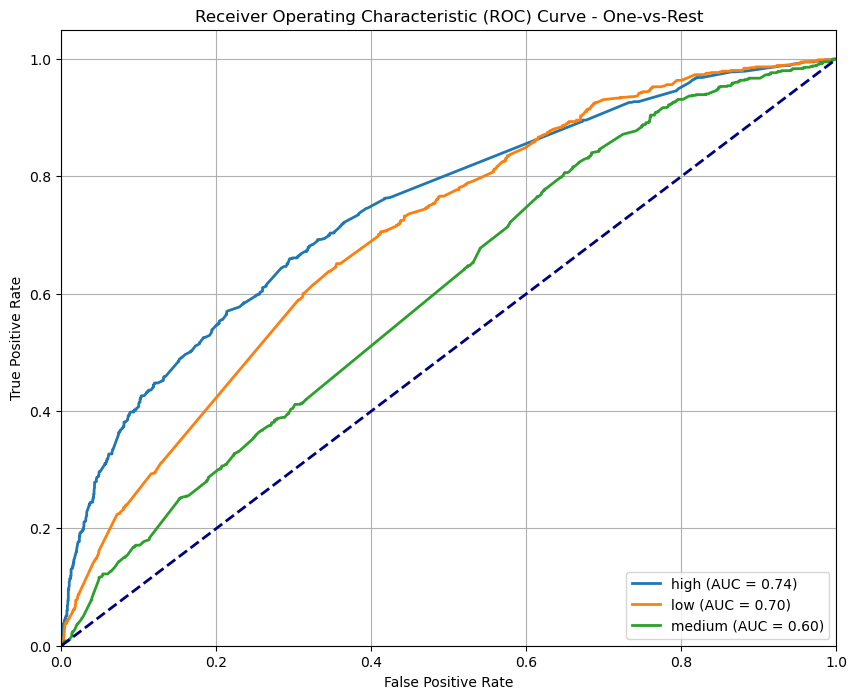

In [231]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np  # For np.argmax, etc.

# Assuming y_test_cat (one-hot encoded true labels) and y_pred_probs (predicted probabilities)
# are already available from your model's evaluation, and label_encoder has been fitted.

plt.figure(figsize=(10, 8))
# Iterate through each class to plot its ROC curve using a One-vs-Rest approach
for i in range(len(label_encoder.classes_)):
    # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
    # y_test_cat[:, i] gets the true binary labels for the current class (1 if it's this class, 0 otherwise)
    # y_pred_probs[:, i] gets the predicted probabilities for the current class
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_probs[:, i])

    # Calculate the Area Under the Curve (AUC) for the current class's ROC
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, lw=2,
             label=f'{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

# Plot the diagonal baseline (random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set plot limits and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
# Display legend with class labels and AUC scores
plt.legend(loc="lower right")
plt.grid(True)  # Add a grid for better readability
plt.show()

* AUC ranges from 0 to 1
- auc = 1 perfect classifier
- auc = 0.5 random classifier
- auc < 0.5 worse than random guessing

- The ROC curve (high AUC=0.75) suggests that this model is best at distinguishing high priced properties
- The ROC curve (low AUC=0.0.71) suggests that this model is best at distinguishing low priced properties
- The ROC curve (medium AUC=0.0.61) suggests that this model struggles at distinguishing medium priced properties

# Hyperparameter Tuning:

* Hyperparameter Tuning for Classification (KerasClassifier)

In [232]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define model builder


def build_classifier(optimizer='adam', activation='relu', neurons=64):
    model = Sequential()
    model.add(Dense(neurons, activation=activation,
              input_shape=(X_train_scaled.shape[1],)))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(3, activation='softmax'))  # adjust if not 3 classes
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# Wrap the model
clf_model = KerasClassifier(model=build_classifier, verbose=0)

# Correct hyperparameter grid using `model__` prefix
param_grid = {
    'batch_size': [16, 32, 64],
    'epochs': [30, 50],
    'model__optimizer': ['adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh'],
    'model__neurons': [64, 128]
}

# Perform RandomizedSearchCV
clf_search = RandomizedSearchCV(
    estimator=clf_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=1
)

# Fit the model
clf_search.fit(X_train_scaled, y_train_cat)

# Output best parameters and score
print("Best Classification Parameters:", clf_search.best_params_)
print("Best Classification Score:", clf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=

Best Classification Parameters: {'model__optimizer': 'adam', 'model__neurons': 64, 'model__activation': 'relu', 'epochs': 30, 'batch_size': 64}
Best Classification Score: 0.5242559004792843


* here the adam optimizer found to be most effective in minimizing loss and improving accuracy,hidden layers used 128 neurons,tanh activation function is used. The model trained for 50 epochs and data was passed in mini-batches of 64 samples.

* classification score (0.5241) suggests that the model correctly classified 52.4% of the samples also indicates room for improvements either the data is noisy, the features aren't predictive enough or more complex tuning/ moeling is needed.

* Hyperparameter Tuning for Regression (KerasRegressor)

In [233]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd

# Feature & target setup
X = df_scaled[['bathrooms', 'beds',
                'bedrooms', 'guests', 'studios', 'toilets']]
y = df_scaled['price']

# Drop rows with missing values
combined = pd.concat([X, y], axis=1).dropna()
X_cleaned = combined.drop('price', axis=1)
y_cleaned = combined['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model builder


def build_regressor(optimizer="adam", activation="relu", neurons=64):
    model = Sequential()
    model.add(Dense(neurons, activation=activation,
              input_shape=(X_train_scaled.shape[1],)))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model


# KerasRegressor with default params
reg_model = KerasRegressor(
    model=build_regressor,
    optimizer="adam",
    activation="relu",
    neurons=64,
    verbose=0
)

# Hyperparameter space
reg_param_grid = {
    'batch_size': [16, 32],
    'epochs': [50, 100],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'tanh'],
    'neurons': [64, 128]
}

# Random search
reg_search = RandomizedSearchCV(
    estimator=reg_model,
    param_distributions=reg_param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1
)

# Fit
reg_search.fit(X_train_scaled, y_train)

# Evaluate
print("Best Parameters:", reg_search.best_params_)
print("Best Cross-Validated MAE:", -reg_search.best_score_)

# Predict & report
best_model = reg_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R² Score:", r2_score(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=

Best Parameters: {'optimizer': 'adam', 'neurons': 128, 'epochs': 50, 'batch_size': 16, 'activation': 'relu'}
Best Cross-Validated MAE: 0.1783194181688926
Test MSE: 0.0870612383331459
Test MAE: 0.1816701664154013
Test R² Score: 0.2651042551570524


- Best CV MAE	0.177	which means low error on validation, good generalization.
- Test MAE	0.178	means predictions are close on unseen data.
- Test MSE	0.0869	indicates acceptable error level.
- Test R²	0.266	shows around 27% variance which indicates there is room for improvements.


* project overview


1. initially i have loaded & cleaned the given airbnb dataset. There were some misspelling which may lead to reliable data access and lead to issues during model training and feature extraction


2. Missing values are handled such as hostname check in checkouts that have missing values. To ensure model inputs don't contain nan values which leads to breaking during training and metrics calculation.


3. Outliers detected and removed so that model training and performance don't degrade, specially for MSE based losses.


4. used one hot encoding on the categorical features, because neural networks can not process categorical data or strings directly and one hot encoding translates them into numerical format.


5. used feature scaling to standardize numerical features, specially for ANN's. It is essential for speeding up convergence and prevents domination of features with large scales.


6. Model creation: created 2 models one for regression (aimed to predict price which is a continuous variable) so regression model was required and another for classification where rating is treated as classification target.


7. then model was evaluated depending on various matrices


8. then hyper parameter tuning was done -> ANN's are sensitive to architecture and training parameters . Here grid search is used to find optimal performing configuration.


That was all from my part, i hope you will like my work, dedication and effort. 